# Final spatial prediction maps for the paper

Retrains every method at the **final hyperparameters used in the paper's
tables** (baselines: `scripts/17_run_best_baselines.py`; LGCP: the winner
from `53_paper_lgcp_hyperparameter_selection.ipynb`, `lr=0.01`, temporal
kernel = RBF + weekly periodic + monthly periodic), with the **same
seeds**, so the metrics reproduce exactly what's already reported.

For each method, on one day of each reporting week -- picked by
`DAY_INDEX` below (default `0` = first day, 2025-05-01 / 2025-11-01, the
one-day-ahead forecast reported in the paper's tables; any value 0-6
selects a different day of that same 7-day test window) -- this
notebook:

1. saves the same two-panel (predicted vs. observed) interpolated spatial
   map PNG that the standalone LGCP/GNN scripts already produce for a
   single day (`plot_daily_interpolated_spatial_maps_separate`), with one
   color scale shared across all 5 methods for that day (rather than each
   method auto-scaling to its own predictions), so the maps are directly
   comparable;
2. saves a CSV of the underlying per-cell data (raw longitude/latitude in
   degrees, observed count, predicted rate) for that method and day, so
   the actual paper figure can be built directly in LaTeX/pgfplots
   instead of from the PNG.

All 5 methods (Last Available Poisson, Global Cell Mean Poisson, Window
Poisson GLM, GNN, LGCP) share one canonical coordinate standardization
(`compute_meta` on the full multi-year dataset), so every plot's Gulf
boundary overlay and axis scale line up consistently -- this mirrors how
`scripts/15_train_gnn.py` already standardizes its own coordinates
against a shared `meta` before calling the same plotting function.

## Config: final hyperparameters and seeds (must match the paper's tables)

In [1]:
YEARS = [2024, 2025]
SEED = 0

# Same reporting weeks as scripts/17_run_best_baselines.py. Each method is
# still trained on the full 7-day window (matching the paper); only one
# day's predictions -- picked by DAY_INDEX below -- are plotted/exported.
REPORT_WEEKS = [
    {"label": "may", "test_start": "2025-05-01", "test_end": "2025-05-07"},
    {"label": "november", "test_start": "2025-11-01", "test_end": "2025-11-07"},
]

# Which day of each 7-day test week to plot/export: 0 = first day (the
# paper's reported one-day-ahead horizon, 2025-05-01 / 2025-11-01), up to
# 6 = last day of the week. Applied as the same offset to both weeks.
DAY_INDEX = 2
assert 0 <= DAY_INDEX <= 6, "DAY_INDEX must be within the 7-day test window (0-6)."

# Covariates shared by every method that takes them (GLM, GNN, LGCP) --
# same fixed set used throughout the paper.
BASELINE_COVARIATE_COLS = [
    "chl", "thetao", "fishing_block", "is_holiday", "is_weekend",
    "cell_lag_1", "cell_lag_7",
]

# --- best hyperparameters, copied verbatim from scripts/17_run_best_baselines.py ---
LAST_AVAILABLE_BEST_MODE = "one_step_ahead"
GLOBAL_CELL_MEAN_MODES = ["frozen_train", "expanding"]  # selected below, as in script 17

GLM_BEST_WINDOW_SIZE = 14
GLM_BEST_ALPHA = 0.01

GNN_BEST_HIDDEN_DIM = 64
GNN_BEST_NUM_LAYERS = 3
GNN_BEST_LR = 0.01

# --- LGCP: winning config from 53_paper_lgcp_hyperparameter_selection.ipynb ---
LGCP_BEST_LR = 0.01
LGCP_BEST_VARIANT = "week_month"  # RBF short-scale + weekly periodic + monthly periodic
LGCP_NUM_STEPS = 5000
LGCP_M_INDUCING = 300
LGCP_NUM_MC = 128
LGCP_MINIBATCH = 1024

BASE_GLM_CONFIG = "config/14_window_poisson_glm.yaml"
BASE_GNN_CONFIG = "config/15_gnn.yaml"
BASE_LGCP_CONFIG = "config/train_basic_lgcp_multi_kernel.yaml"

RESULTS_DIR_NAME = "reports/paper/lgcp_two_week_2025_05_11/spatial_predictions"

print("Config loaded. Methods: Last Available Poisson, Global Cell Mean Poisson, Window Poisson GLM, GNN, LGCP")

Config loaded. Methods: Last Available Poisson, Global Cell Mean Poisson, Window Poisson GLM, GNN, LGCP


## Setup: imports, module loading, shared coordinate standardization

In [2]:
from __future__ import annotations

import importlib.util
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.metrics_lgcp import evaluate_metrics
from src.data.multi_year import load_parquet_years
from src.visualization.viz_lgcp import plot_daily_interpolated_spatial_maps_separate


def load_script_module(name, relpath):
    spec = importlib.util.spec_from_file_location(name, PROJECT_ROOT / relpath)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


last_avail = load_script_module("last_avail", "scripts/13_evaluate_last_available_poisson.py")
global_cell_mean = load_script_module("global_cell_mean", "scripts/12b_global_cell_mean.py")
window_glm = load_script_module("window_glm", "scripts/14_train_window_poisson_glm.py")
gnn_mod = load_script_module("gnn_mod", "scripts/15_train_gnn.py")
train_lgcp = load_script_module("train_lgcp", "scripts/11_train_lgcp.py")

RESULTS_DIR = PROJECT_ROOT / RESULTS_DIR_NAME
PLOTS_DIR = RESULTS_DIR / "plots"
CSV_DIR = RESULTS_DIR / "csv"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

GULF_CSV_PATH = str(PROJECT_ROOT / "data/raw/ts_gulf_coords.csv")

# --- one canonical meta (lon/lat mean+std) shared by every method's plot ---
_df_full = load_parquet_years(str(PROJECT_ROOT / "data/processed/cpr_gfw.parquet"), YEARS)
META = train_lgcp.compute_meta(_df_full)

# --- corrected week/month periods, recomputed exactly as in notebook 53 ---
_df_full["date"] = pd.to_datetime(_df_full["date"])
_span_days = (_df_full["date"].max() - _df_full["date"].min()).days
PERIODS = {"week": 7 / _span_days, "month": 30.44 / _span_days, "year": 365.25 / _span_days}

print(f"Modules loaded OK. Results will be saved under: {RESULTS_DIR}")
print(f"Canonical meta: lon_mean={META['lon_mean']:.4f} lon_std={META['lon_std']:.4f} "
      f"lat_mean={META['lat_mean']:.4f} lat_std={META['lat_std']:.4f}")

Modules loaded OK. Results will be saved under: /home/rdoz/PhD/AIPS/reports/paper/lgcp_two_week_2025_05_11/spatial_predictions
Canonical meta: lon_mean=13.3980 lon_std=0.1792 lat_mean=45.6305 lat_std=0.0623


## Shared helper: standardize coords, save CSV, collect for later plotting

`collect_day` filters everything to the single target date and writes a
companion CSV of the raw per-cell points for that method/day. Plotting is
deferred to its own step once every method has run, so that the color
scale can be shared across methods (see "Spatial plots" below) instead of
each method auto-scaling to its own predictions.

In [3]:
def standardize_lonlat(lon, lat, meta):
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
    return np.column_stack([
        (lon - meta["lon_mean"]) / meta["lon_std"],
        (lat - meta["lat_mean"]) / meta["lat_std"],
    ])


def collect_day(method_name, week_label, week_start, coords_std, lon_raw, lat_raw, test_dates, y_true, y_pred):
    test_dates_norm = pd.to_datetime(np.asarray(test_dates)).normalize()
    target_date = pd.Timestamp(week_start).normalize() + pd.Timedelta(days=DAY_INDEX)
    mask = np.asarray(test_dates_norm == target_date)
    date_str = target_date.strftime("%Y-%m-%d")

    y_true = np.asarray(y_true, dtype=float)[mask]
    y_pred = np.asarray(y_pred, dtype=float)[mask]
    lon_raw = np.asarray(lon_raw, dtype=float)[mask]
    lat_raw = np.asarray(lat_raw, dtype=float)[mask]
    coords_std = np.asarray(coords_std, dtype=float)[mask]
    test_dates_day = np.asarray(test_dates)[mask]

    out_df = pd.DataFrame({
        "method": method_name,
        "week": week_label,
        "date": date_str,
        "longitude": lon_raw,
        "latitude": lat_raw,
        "y_true": y_true,
        "y_pred": y_pred,
    })
    csv_path = CSV_DIR / f"spatial_predictions_{method_name}_{week_label}_{date_str}.csv"
    out_df.to_csv(csv_path, index=False)
    print(f"  [{method_name} | {week_label} | {date_str}] {len(out_df)} points -> {csv_path.name}")

    day_records.append({
        "method": method_name, "week": week_label, "date_str": date_str,
        "coords_std": coords_std, "test_dates": test_dates_day,
        "y_true": y_true, "y_pred": y_pred,
    })
    return out_df


all_day_rows = []
day_records = []
print("Helpers defined.")

Helpers defined.


## Last Available Poisson

In [4]:
la_cfg = last_avail.load_config(None)
la_cfg["years"] = YEARS
la_cfg["parquet_path"] = str(PROJECT_ROOT / la_cfg["parquet_path"])

for week in REPORT_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    (_, _, _, _, _, test_y, _, df_la) = last_avail.prepare_data(
        la_cfg["parquet_path"], train_fraction=la_cfg["train_fraction"], random_seed=la_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
        years=YEARS,
    )
    df_la["date"] = pd.to_datetime(df_la["date"])
    train_mask, test_mask = last_avail.make_day_split_masks(
        df=df_la, train_fraction=la_cfg["train_fraction"], random_seed=la_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    test_dates = df_la.loc[test_mask, "date"].values
    lon_raw = df_la.loc[test_mask, "longitude"].values
    lat_raw = df_la.loc[test_mask, "latitude"].values
    preds = last_avail.build_last_available_predictions(
        df=df_la, train_mask=train_mask, test_mask=test_mask, mode=LAST_AVAILABLE_BEST_MODE
    )
    coords_std = standardize_lonlat(lon_raw, lat_raw, META)

    all_day_rows.append(collect_day("last_available", label, test_start, coords_std, lon_raw, lat_raw, test_dates, test_y, preds))

print("Last Available Poisson done.")

  [last_available | may | 2025-05-03] 49 points -> spatial_predictions_last_available_may_2025-05-03.csv
  [last_available | november | 2025-11-03] 49 points -> spatial_predictions_last_available_november_2025-11-03.csv
Last Available Poisson done.


## Global Cell Mean Poisson

Both modes are evaluated on the full week to pick the better one (by
`mean_ll_obs` averaged across weeks, exactly as in script 17); the
winning mode's predictions are then used for the first-day plot/CSV.

In [5]:
target_col = "ais_vessels_count"
date_col = "date"
cell_cols = ["longitude", "latitude"]
gcm_parquet_path = str(PROJECT_ROOT / "data/processed/cpr_gfw.parquet")

df_gcm = global_cell_mean.load_parquet_years(gcm_parquet_path, YEARS)
df_gcm[date_col] = pd.to_datetime(df_gcm[date_col]).dt.normalize()

per_week_preds = {mode: {} for mode in GLOBAL_CELL_MEAN_MODES}
avg_ll_scores = {mode: [] for mode in GLOBAL_CELL_MEAN_MODES}

for week in REPORT_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    train_mask, test_mask = global_cell_mean.make_day_split_masks(
        df=df_gcm, train_fraction=0.9, random_seed=42,
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    test_df = df_gcm.loc[test_mask]
    y_test = test_df[target_col].values.astype(float)
    test_dates = test_df[date_col].values
    lon_raw = test_df["longitude"].values
    lat_raw = test_df["latitude"].values

    for mode in GLOBAL_CELL_MEAN_MODES:
        if mode == "frozen_train":
            preds = global_cell_mean.build_frozen_train_cell_mean_predictions(
                df=df_gcm, train_mask=train_mask, test_mask=test_mask,
                target_col=target_col, cell_cols=cell_cols,
            )
        else:
            preds = global_cell_mean.build_expanding_cell_mean_predictions(
                df=df_gcm, train_mask=train_mask, test_mask=test_mask,
                target_col=target_col, date_col=date_col, cell_cols=cell_cols,
            )
        metrics = evaluate_metrics(y_test, preds, test_dates)
        per_week_preds[mode][label] = (test_dates, y_test, preds, lon_raw, lat_raw)
        avg_ll_scores[mode].append(metrics["mean_ll_obs"])

avg_ll = {mode: float(np.mean(scores)) for mode, scores in avg_ll_scores.items()}
best_gcm_mode = max(avg_ll.items(), key=lambda item: item[1])[0]
print(f"[Global Cell Mean] selected mode={best_gcm_mode}  (avg mean_ll_obs: " + ", ".join(f"{m}={v:.4f}" for m, v in avg_ll.items()) + ")")

for week in REPORT_WEEKS:
    label, test_start = week["label"], week["test_start"]
    test_dates, y_test, preds, lon_raw, lat_raw = per_week_preds[best_gcm_mode][label]
    coords_std = standardize_lonlat(lon_raw, lat_raw, META)
    all_day_rows.append(collect_day("global_cell_mean", label, test_start, coords_std, lon_raw, lat_raw, test_dates, y_test, preds))

print("Global Cell Mean Poisson done.")

[Global Cell Mean] selected mode=expanding  (avg mean_ll_obs: frozen_train=-0.6339, expanding=-0.6314)
  [global_cell_mean | may | 2025-05-03] 49 points -> spatial_predictions_global_cell_mean_may_2025-05-03.csv
  [global_cell_mean | november | 2025-11-03] 49 points -> spatial_predictions_global_cell_mean_november_2025-11-03.csv
Global Cell Mean Poisson done.


## Window Poisson GLM

In [6]:
glm_cfg = window_glm.load_config(str(PROJECT_ROOT / BASE_GLM_CONFIG))
glm_cfg["years"] = YEARS
glm_cfg["parquet_path"] = str(PROJECT_ROOT / glm_cfg["parquet_path"])
glm_cfg["window_size"] = GLM_BEST_WINDOW_SIZE
glm_cfg["covariate_cols"] = BASELINE_COVARIATE_COLS

df_glm_raw = window_glm.load_parquet_years(glm_cfg["parquet_path"], YEARS)
df_glm_raw["date"] = pd.to_datetime(df_glm_raw["date"])

for week in REPORT_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    df_win, feature_cols = window_glm.build_window_dataframe(df_glm_raw, glm_cfg)
    train_mask, test_mask = window_glm.make_split_masks(
        dates=df_win["date"], split_strategy="fixed_test_window",
        train_fraction=glm_cfg["train_fraction"], random_seed=glm_cfg["data_seed"],
        test_start_date=test_start, test_end_date=test_end,
    )
    X = df_win[feature_cols].values.astype(np.float32)
    y = df_win[glm_cfg["target_col"]].values.astype(np.float32)
    dts = df_win["date"].values
    lon_raw = df_win["longitude"].values
    lat_raw = df_win["latitude"].values

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    test_dates = dts[test_mask]
    lon_test = lon_raw[test_mask]
    lat_test = lat_raw[test_mask]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = PoissonRegressor(alpha=GLM_BEST_ALPHA, max_iter=glm_cfg["max_iter"])
    model.fit(X_train_s, y_train)
    preds = np.clip(model.predict(X_test_s), 0, None)

    coords_std = standardize_lonlat(lon_test, lat_test, META)
    all_day_rows.append(collect_day("window_glm", label, test_start, coords_std, lon_test, lat_test, test_dates, y_test, preds))

print("Window Poisson GLM done.")

  [window_glm | may | 2025-05-03] 49 points -> spatial_predictions_window_glm_may_2025-05-03.csv
  [window_glm | november | 2025-11-03] 49 points -> spatial_predictions_window_glm_november_2025-11-03.csv
Window Poisson GLM done.


## GNN

In [7]:
gnn_cfg = gnn_mod.load_config(str(PROJECT_ROOT / BASE_GNN_CONFIG))
gnn_cfg["years"] = YEARS
gnn_cfg["parquet_path"] = str(PROJECT_ROOT / gnn_cfg["parquet_path"])
gnn_cfg["covariate_cols"] = BASELINE_COVARIATE_COLS
device = torch.device(gnn_cfg.get("device", "cpu"))

df_gnn = gnn_mod.load_parquet_years(gnn_cfg["parquet_path"], YEARS)
df_gnn["date"] = pd.to_datetime(df_gnn["date"])
df_feat, feature_cols = gnn_mod.build_node_features(df_gnn, gnn_cfg)
X, Y, dates, cell_coords = gnn_mod.build_graph_tensors(df_feat, feature_cols, gnn_cfg["target_col"])
n_dates, n_cells, n_features = X.shape

adj = gnn_mod.build_grid_adjacency(
    cell_coords[["longitude", "latitude"]].to_numpy(), connectivity=gnn_cfg.get("adjacency", "queen")
)
adj_norm = gnn_mod.normalize_adjacency(adj)
adj_norm_t = torch.tensor(adj_norm, dtype=torch.float32, device=device)

lon_cells = cell_coords["longitude"].to_numpy()
lat_cells = cell_coords["latitude"].to_numpy()

for week in REPORT_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    train_mask, test_mask = gnn_mod.make_day_split_masks(
        df=pd.DataFrame({"date": dates}), train_fraction=gnn_cfg["train_fraction"], random_seed=gnn_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    X_train, Y_train = X[train_mask], Y[train_mask]
    X_test, Y_test = X[test_mask], Y[test_mask]
    dates_test = dates[test_mask]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_features))
    X_train_model = scaler.transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_test_model = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

    X_train_t = torch.tensor(X_train_model, dtype=torch.float32, device=device)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
    X_test_t = torch.tensor(X_test_model, dtype=torch.float32, device=device)

    torch.manual_seed(SEED)
    model = gnn_mod.SpatioTemporalGNN(
        in_dim=n_features, hidden_dim=GNN_BEST_HIDDEN_DIM, num_layers=GNN_BEST_NUM_LAYERS, dropout=gnn_cfg["dropout"],
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=GNN_BEST_LR, weight_decay=gnn_cfg["weight_decay"])

    model.train()
    for epoch in range(1, int(gnn_cfg["num_epochs"]) + 1):
        optimizer.zero_grad()
        rate_train = model(X_train_t, adj_norm_t)
        loss = gnn_mod.poisson_nll(rate_train, Y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        rate_test = model(X_test_t, adj_norm_t).cpu().numpy()
    rate_test = np.clip(rate_test, 0, None)

    y_test_flat = Y_test.reshape(-1)
    rate_test_flat = rate_test.reshape(-1)
    test_dates_flat = np.repeat(dates_test, n_cells)
    lon_flat = np.tile(lon_cells, len(dates_test))
    lat_flat = np.tile(lat_cells, len(dates_test))

    coords_std = standardize_lonlat(lon_flat, lat_flat, META)
    all_day_rows.append(collect_day("gnn", label, test_start, coords_std, lon_flat, lat_flat, test_dates_flat, y_test_flat, rate_test_flat))

print("GNN done.")

Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
  [gnn | may | 2025-05-03] 49 points -> spatial_predictions_gnn_may_2025-05-03.csv
  [gnn | november | 2025-11-03] 49 points -> spatial_predictions_gnn_november_2025-11-03.csv
GNN done.


## LGCP

Uses the winning `(lr, kernel)` config from notebook 53 at the full
budget (`num_steps=5000`, `num_mc=128`, `M_inducing=300`,
`minibatch=1024`), zero-gate disabled -- the same config that produced
`lgcp_metrics_{full_week,first_3_days,first_day}.csv`.

Note: LGCP's `test_coords` come back already standardized by its own
train-only coordinate scaler (`prepare_data`'s `coord_scaler`, fit on the
training split only) rather than by the shared canonical `META` (fit on
the full dataset). This tiny discrepancy already exists in the standalone
`scripts/11_train_lgcp.py` plot call -- train excludes only the 7-day
test window out of ~2 years of data, so the two scalings are practically
identical, and this notebook simply preserves that existing convention.

In [8]:
def _spatial_kernels():
    return [{
        "type": "RBF",
        "hyperparameters": {"lengthscale": 0.1, "variance": 2.0},
        "trainable": {"lengthscale": False, "variance": True},
    }]


def _rbf_short_scale():
    return {
        "type": "RBF",
        "hyperparameters": {"lengthscale": 0.01, "variance": 0.5},
        "trainable": {"lengthscale": False, "variance": True},
    }


def _periodic(period_name):
    return {
        "type": "periodic",
        "hyperparameters": {"lengthscale": 0.2, "variance": 0.2, "period": PERIODS[period_name]},
        "trainable": {"lengthscale": True, "variance": True, "period": False},
    }


LGCP_TEMPORAL_PERIODS = {"week_month": ["week", "month"]}[LGCP_BEST_VARIANT]
LGCP_MODEL_CFG = {
    "spatial_composition": "sum",
    "temporal_composition": "sum",
    "spatial_kernels": _spatial_kernels(),
    "temporal_kernels": [_rbf_short_scale()] + [_periodic(p) for p in LGCP_TEMPORAL_PERIODS],
}

for week in REPORT_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    base_cfg = train_lgcp.load_config(str(PROJECT_ROOT / BASE_LGCP_CONFIG))
    base_cfg["years"] = YEARS
    base_cfg["parquet_path"] = str(PROJECT_ROOT / base_cfg["parquet_path"])
    base_cfg["covariate_cols"] = BASELINE_COVARIATE_COLS
    base_cfg["M_inducing"] = LGCP_M_INDUCING
    base_cfg["model"] = LGCP_MODEL_CFG

    (train_coords, train_covs, train_y, test_coords, test_covs, test_y, scalers, df_lgcp) = train_lgcp.prepare_data(
        base_cfg["parquet_path"], train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window", covariate_cols=base_cfg["covariate_cols"],
        test_start_date=test_start, test_end_date=test_end,
        lag_features=base_cfg.get("lag_features"), years=YEARS,
    )
    df_lgcp["date"] = pd.to_datetime(df_lgcp["date"])
    _, test_mask = train_lgcp.make_day_split_masks(
        df=df_lgcp, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    test_dates = df_lgcp.loc[test_mask, "date"].values
    lon_raw = df_lgcp.loc[test_mask, "longitude"].values
    lat_raw = df_lgcp.loc[test_mask, "latitude"].values

    run_cfg = dict(base_cfg)
    run_cfg["kernel_config"] = train_lgcp.normalize_kernel_config(run_cfg)
    run_cfg["lr"] = LGCP_BEST_LR
    run_cfg["num_mc"] = LGCP_NUM_MC
    run_cfg["num_steps"] = LGCP_NUM_STEPS
    run_cfg["minibatch"] = LGCP_MINIBATCH
    run_cfg["log_every"] = LGCP_NUM_STEPS
    run_cfg["np_seed"] = SEED

    train_lgcp.set_seeds(SEED)
    model = train_lgcp.SparseLGCP(
        train_coords, train_covs, train_y, kernel_config=run_cfg["kernel_config"],
        M_inducing=run_cfg["M_inducing"], device=run_cfg["device"], np_seed=SEED,
    )
    train_lgcp.configure_log_noise(model, run_cfg)
    train_lgcp.train(model, run_cfg)

    rate_mean_test, _, _ = model.predict_rate(test_coords, test_covs, num_samples=run_cfg["num_pred_samples"])
    # zero-gate stays disabled, matching notebook 53's final confirmation run

    coords_std_lgcp = test_coords[:, :2]  # already standardized by prepare_data's own coord_scaler
    all_day_rows.append(collect_day("lgcp", label, test_start, coords_std_lgcp, lon_raw, lat_raw, test_dates, test_y, rate_mean_test))

print("LGCP done.")

Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=18461.5176  ll=-790.1298  kl=86.3715  (0.1s)
[  5000/5000]  loss=9865.5225  ll=-420.3402  kl=90.1492  (363.3s)
  [lgcp | may | 2025-05-03] 49 points -> spatial_predictions_lgcp_may_2025-05-03.csv
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=21502.1055  ll=-667.9659  kl=86.7523  (0.1s)
[  5000/5000]  loss=12964.4365  ll=-401.2320  kl=100.7207  (368.4s)
  [lgcp | november | 2025-11-03] 49 points -> spatial_predictions_lgcp_november_2025-11-03.csv
LGCP done.


## Spatial plots (shared color scale per day)

For each day, the color scale (`vmax`) is computed once across all 5
methods' observed and predicted values, then reused for every method's
plot -- so maps for the same day are directly visually comparable, rather
than each method auto-scaling to its own range.

In [9]:
from collections import defaultdict

records_by_day = defaultdict(list)
for rec in day_records:
    records_by_day[(rec["week"], rec["date_str"])].append(rec)

for (week_label, date_str), recs in records_by_day.items():
    day_vmax = max(
        max(float(np.nanmax(r["y_true"])), float(np.nanmax(r["y_pred"])), 1e-8)
        for r in recs
    )
    print(f"[{week_label} | {date_str}] shared vmax={day_vmax:.4f} across {len(recs)} methods")

    for r in recs:
        plot_daily_interpolated_spatial_maps_separate(
            test_coords=r["coords_std"],
            test_dates=r["test_dates"],
            y_true=r["y_true"],
            rate_mean=r["y_pred"],
            meta=META,
            gulf_csv_path=GULF_CSV_PATH,
            out_dir=PLOTS_DIR,
            cmap="viridis",
            max_days=1,
            filename_template=f"spatial_map_{r['method']}_{week_label}_{{date}}.png",
            vmax=day_vmax,
        )

print("\nAll spatial plots saved with per-day shared color scale.")

[may | 2025-05-03] shared vmax=3.0000 across 5 methods
Using shared color scale: vmin=0, vmax=3.0000
Using shared color scale: vmin=0, vmax=3.0000
Using shared color scale: vmin=0, vmax=3.0000
Using shared color scale: vmin=0, vmax=3.0000
Using shared color scale: vmin=0, vmax=3.0000
[november | 2025-11-03] shared vmax=4.0000 across 5 methods
Using shared color scale: vmin=0, vmax=4.0000
Using shared color scale: vmin=0, vmax=4.0000
Using shared color scale: vmin=0, vmax=4.0000
Using shared color scale: vmin=0, vmax=4.0000
Using shared color scale: vmin=0, vmax=4.0000

All spatial plots saved with per-day shared color scale.


## Combined CSV and summary

In [10]:
combined_df = pd.concat(all_day_rows, ignore_index=True)
combined_path = CSV_DIR / "spatial_predictions_all_methods.csv"
combined_df.to_csv(combined_path, index=False)

print(f"Combined CSV ({len(combined_df)} rows) -> {combined_path}")
print(f"\nPer-method-per-day files saved under: {CSV_DIR}")
print(f"Plots saved under: {PLOTS_DIR}")
display(combined_df.groupby(["method", "week"]).size().rename("n_points"))

Combined CSV (490 rows) -> /home/rdoz/PhD/AIPS/reports/paper/lgcp_two_week_2025_05_11/spatial_predictions/csv/spatial_predictions_all_methods.csv

Per-method-per-day files saved under: /home/rdoz/PhD/AIPS/reports/paper/lgcp_two_week_2025_05_11/spatial_predictions/csv
Plots saved under: /home/rdoz/PhD/AIPS/reports/paper/lgcp_two_week_2025_05_11/spatial_predictions/plots


method            week    
global_cell_mean  may         49
                  november    49
gnn               may         49
                  november    49
last_available    may         49
                  november    49
lgcp              may         49
                  november    49
window_glm        may         49
                  november    49
Name: n_points, dtype: int64

## Inline plots

### May — 2025-05-03

**Last Available Poisson**

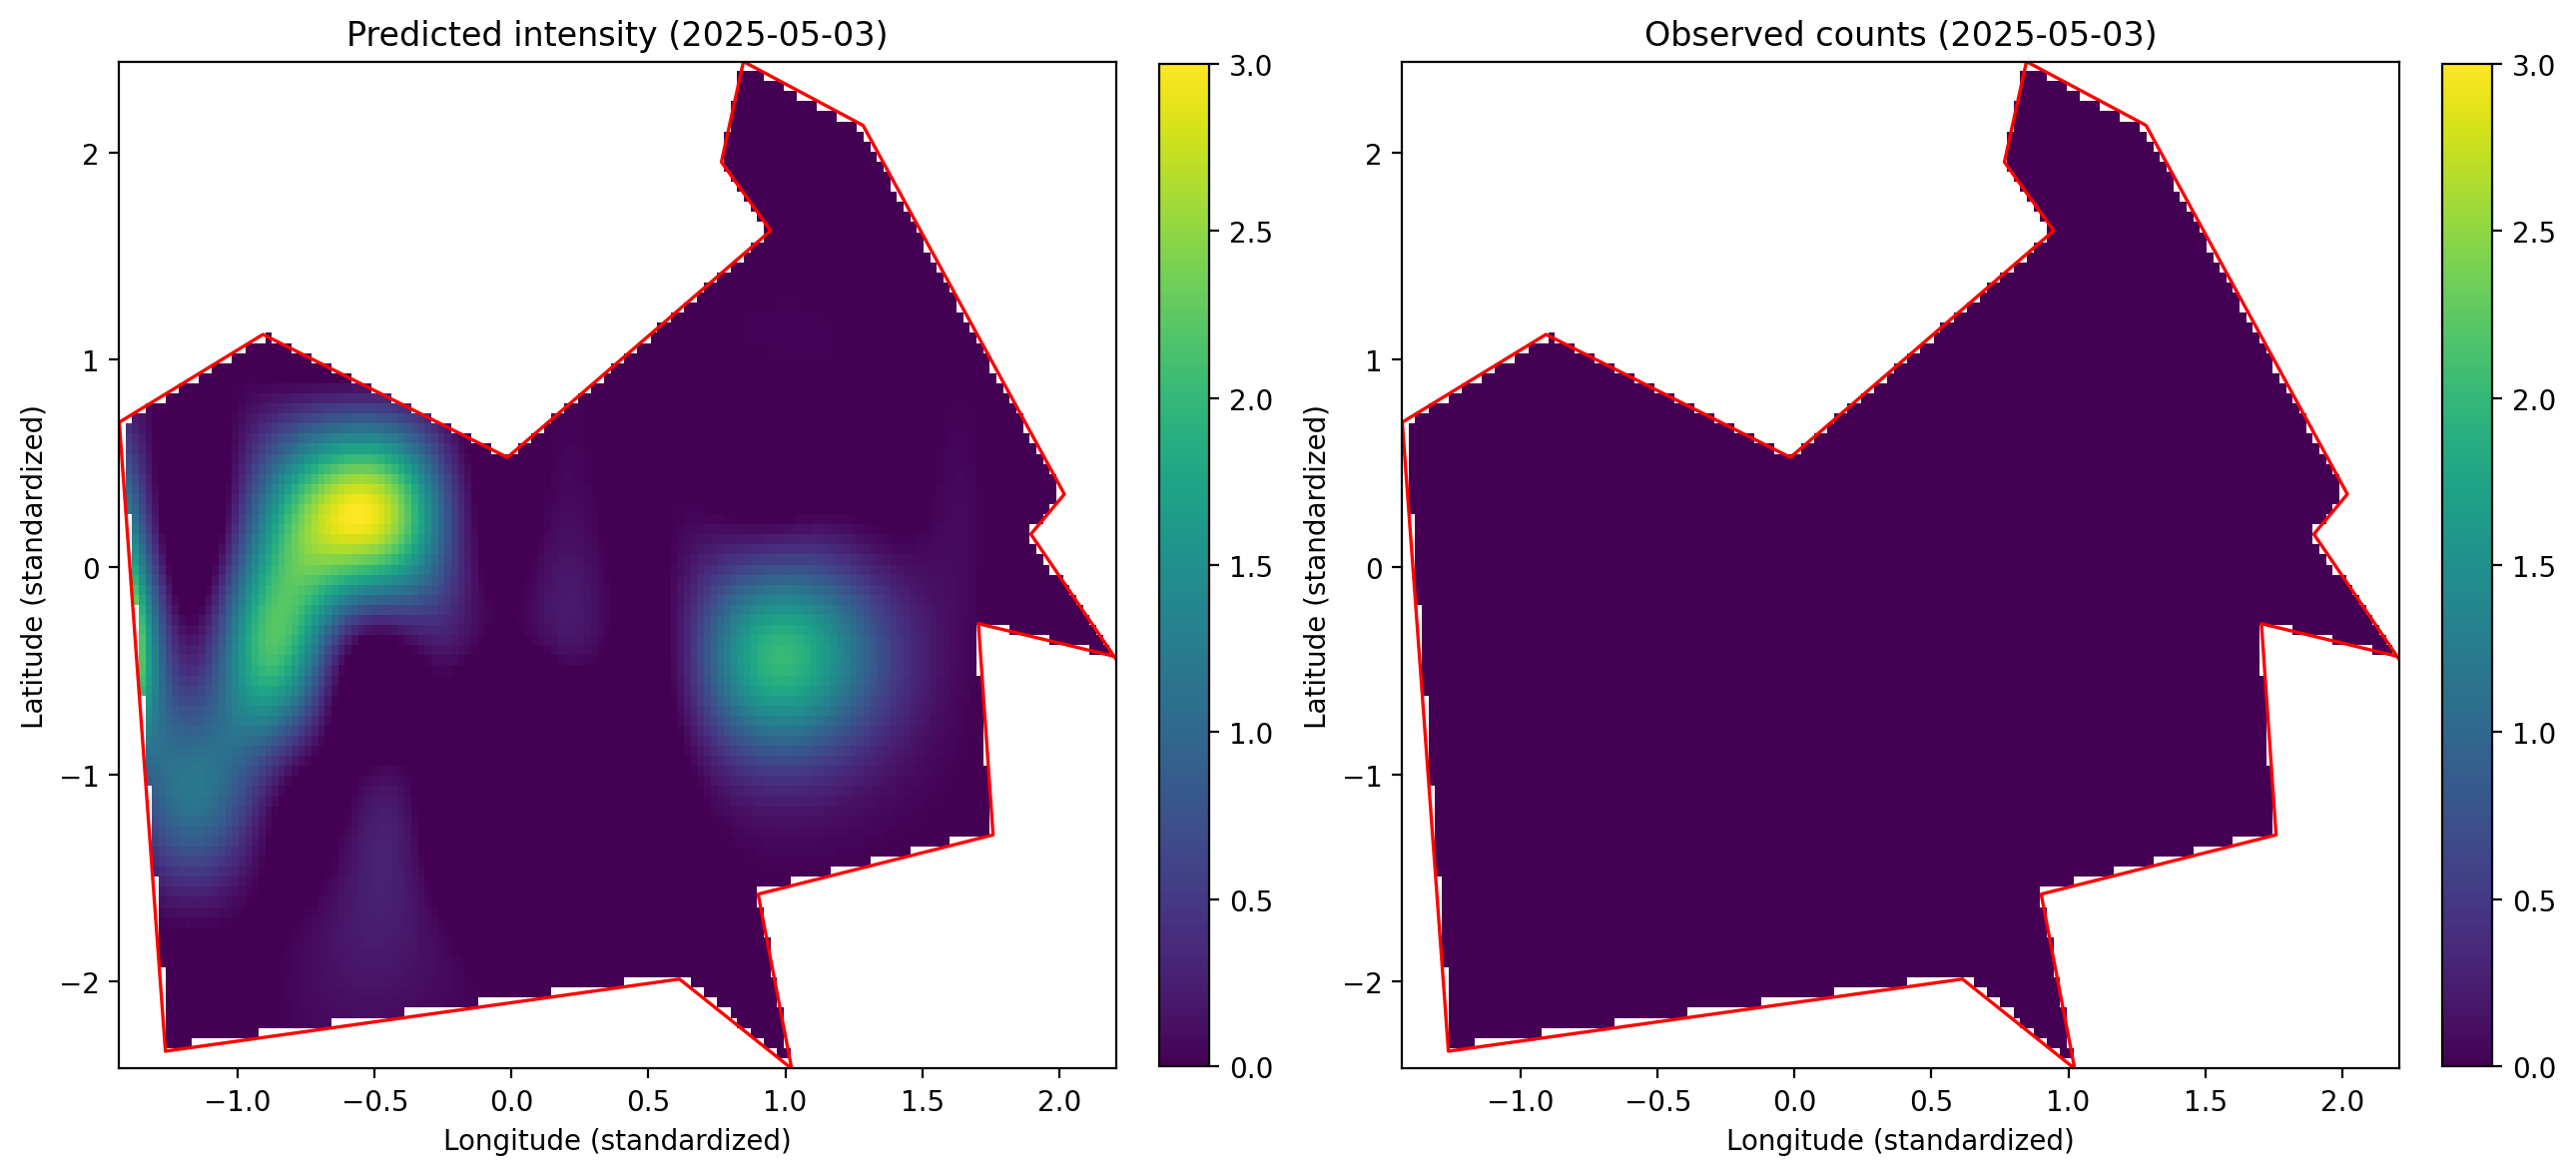

**Global Cell Mean Poisson**

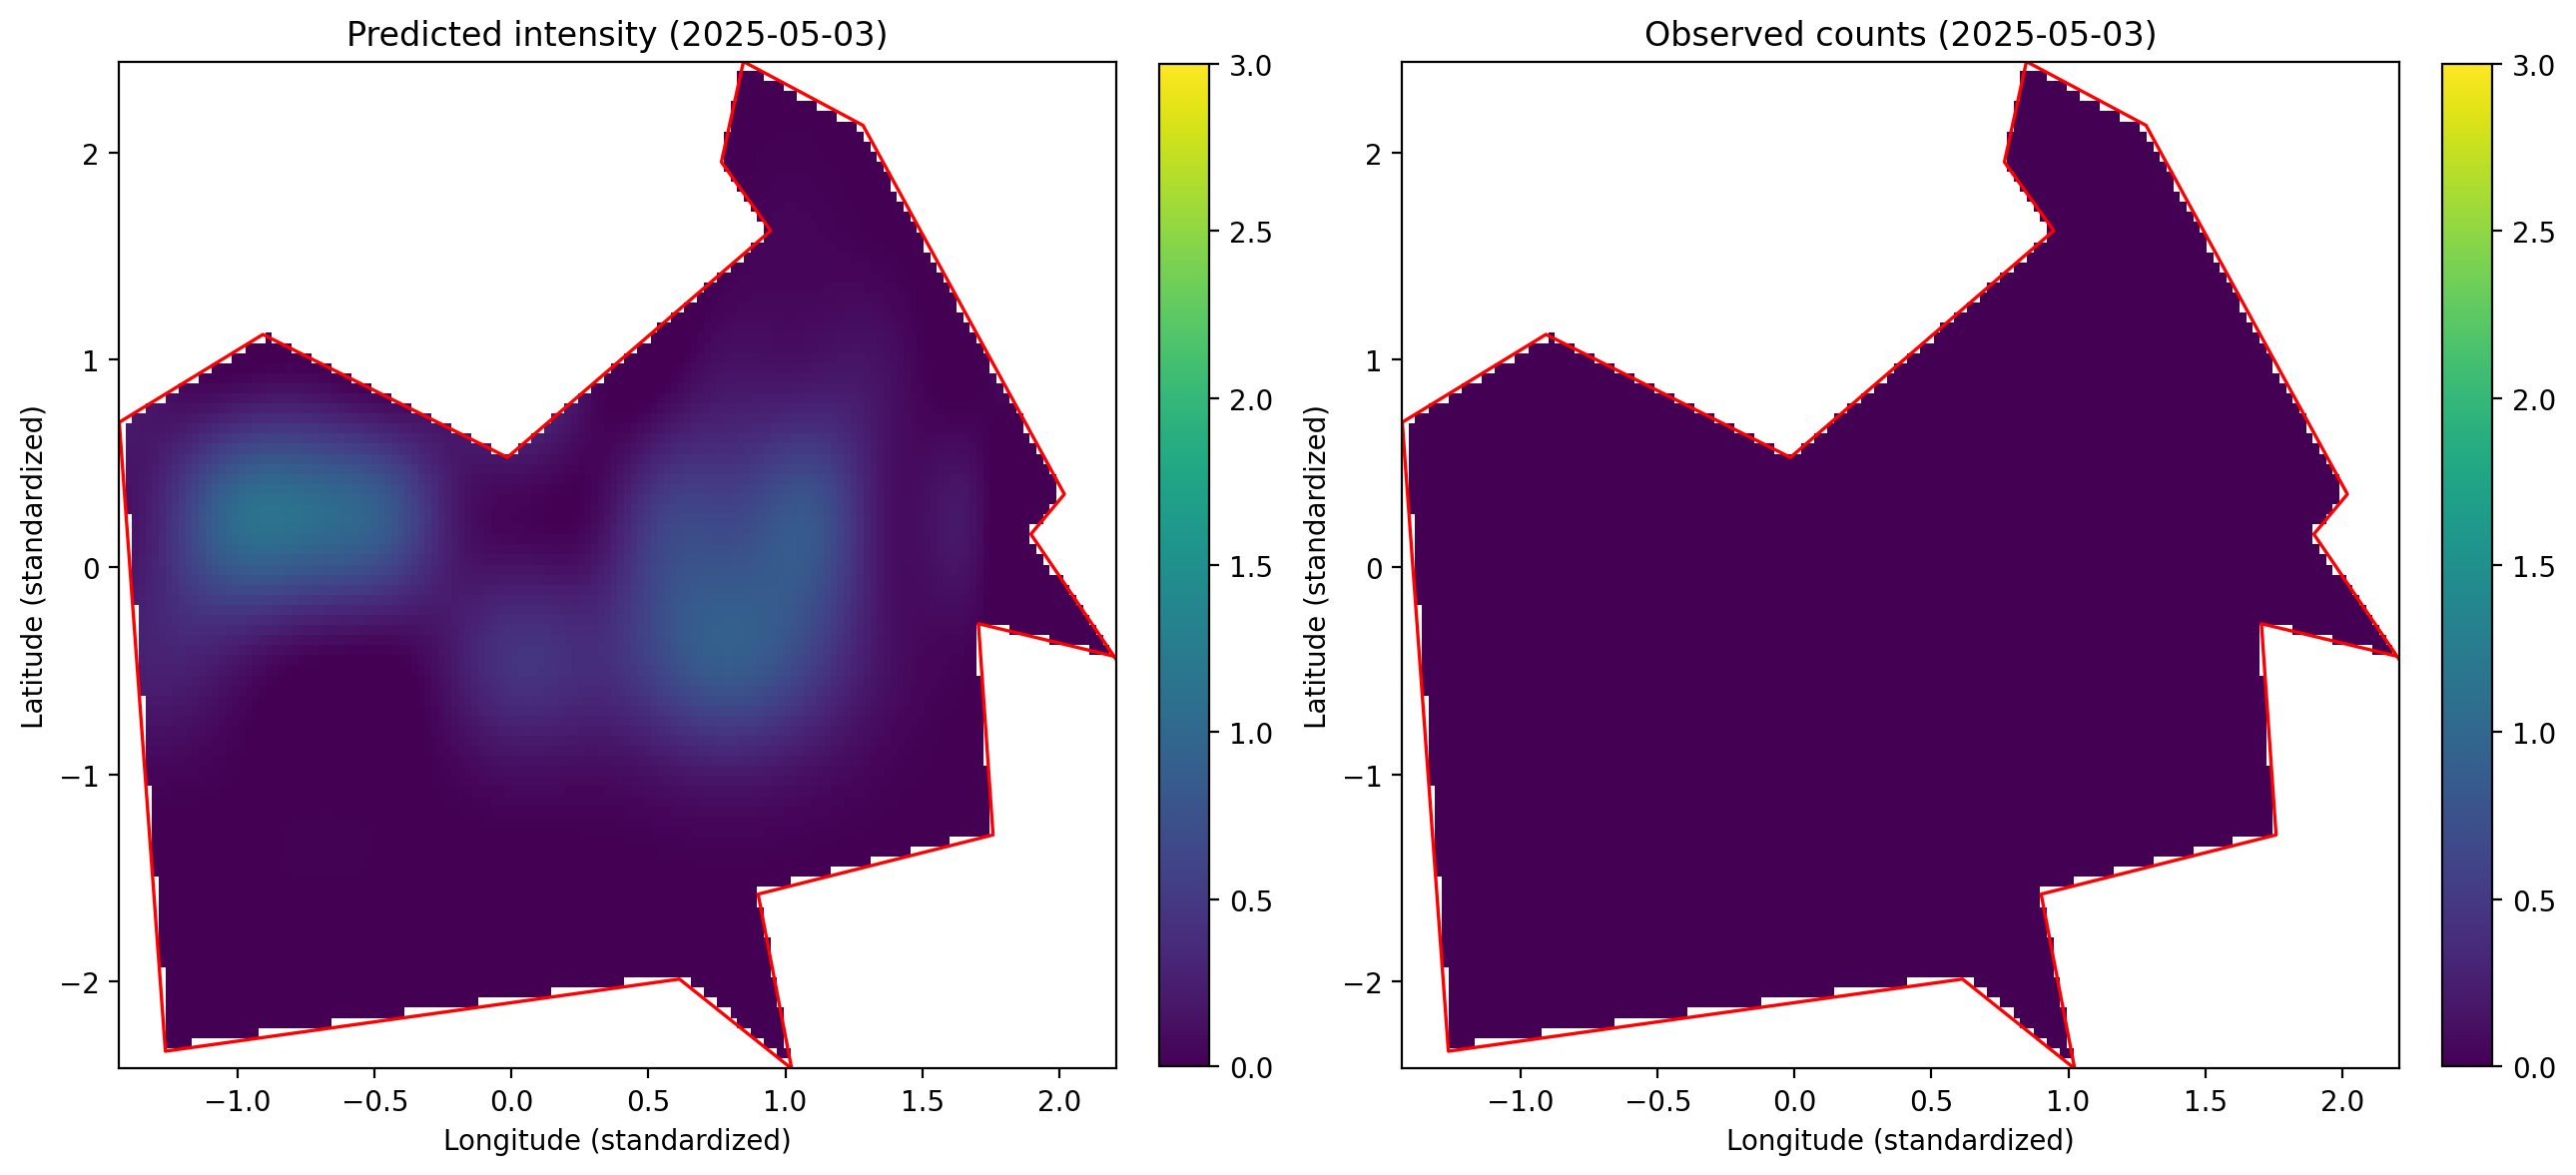

**Window Poisson GLM**

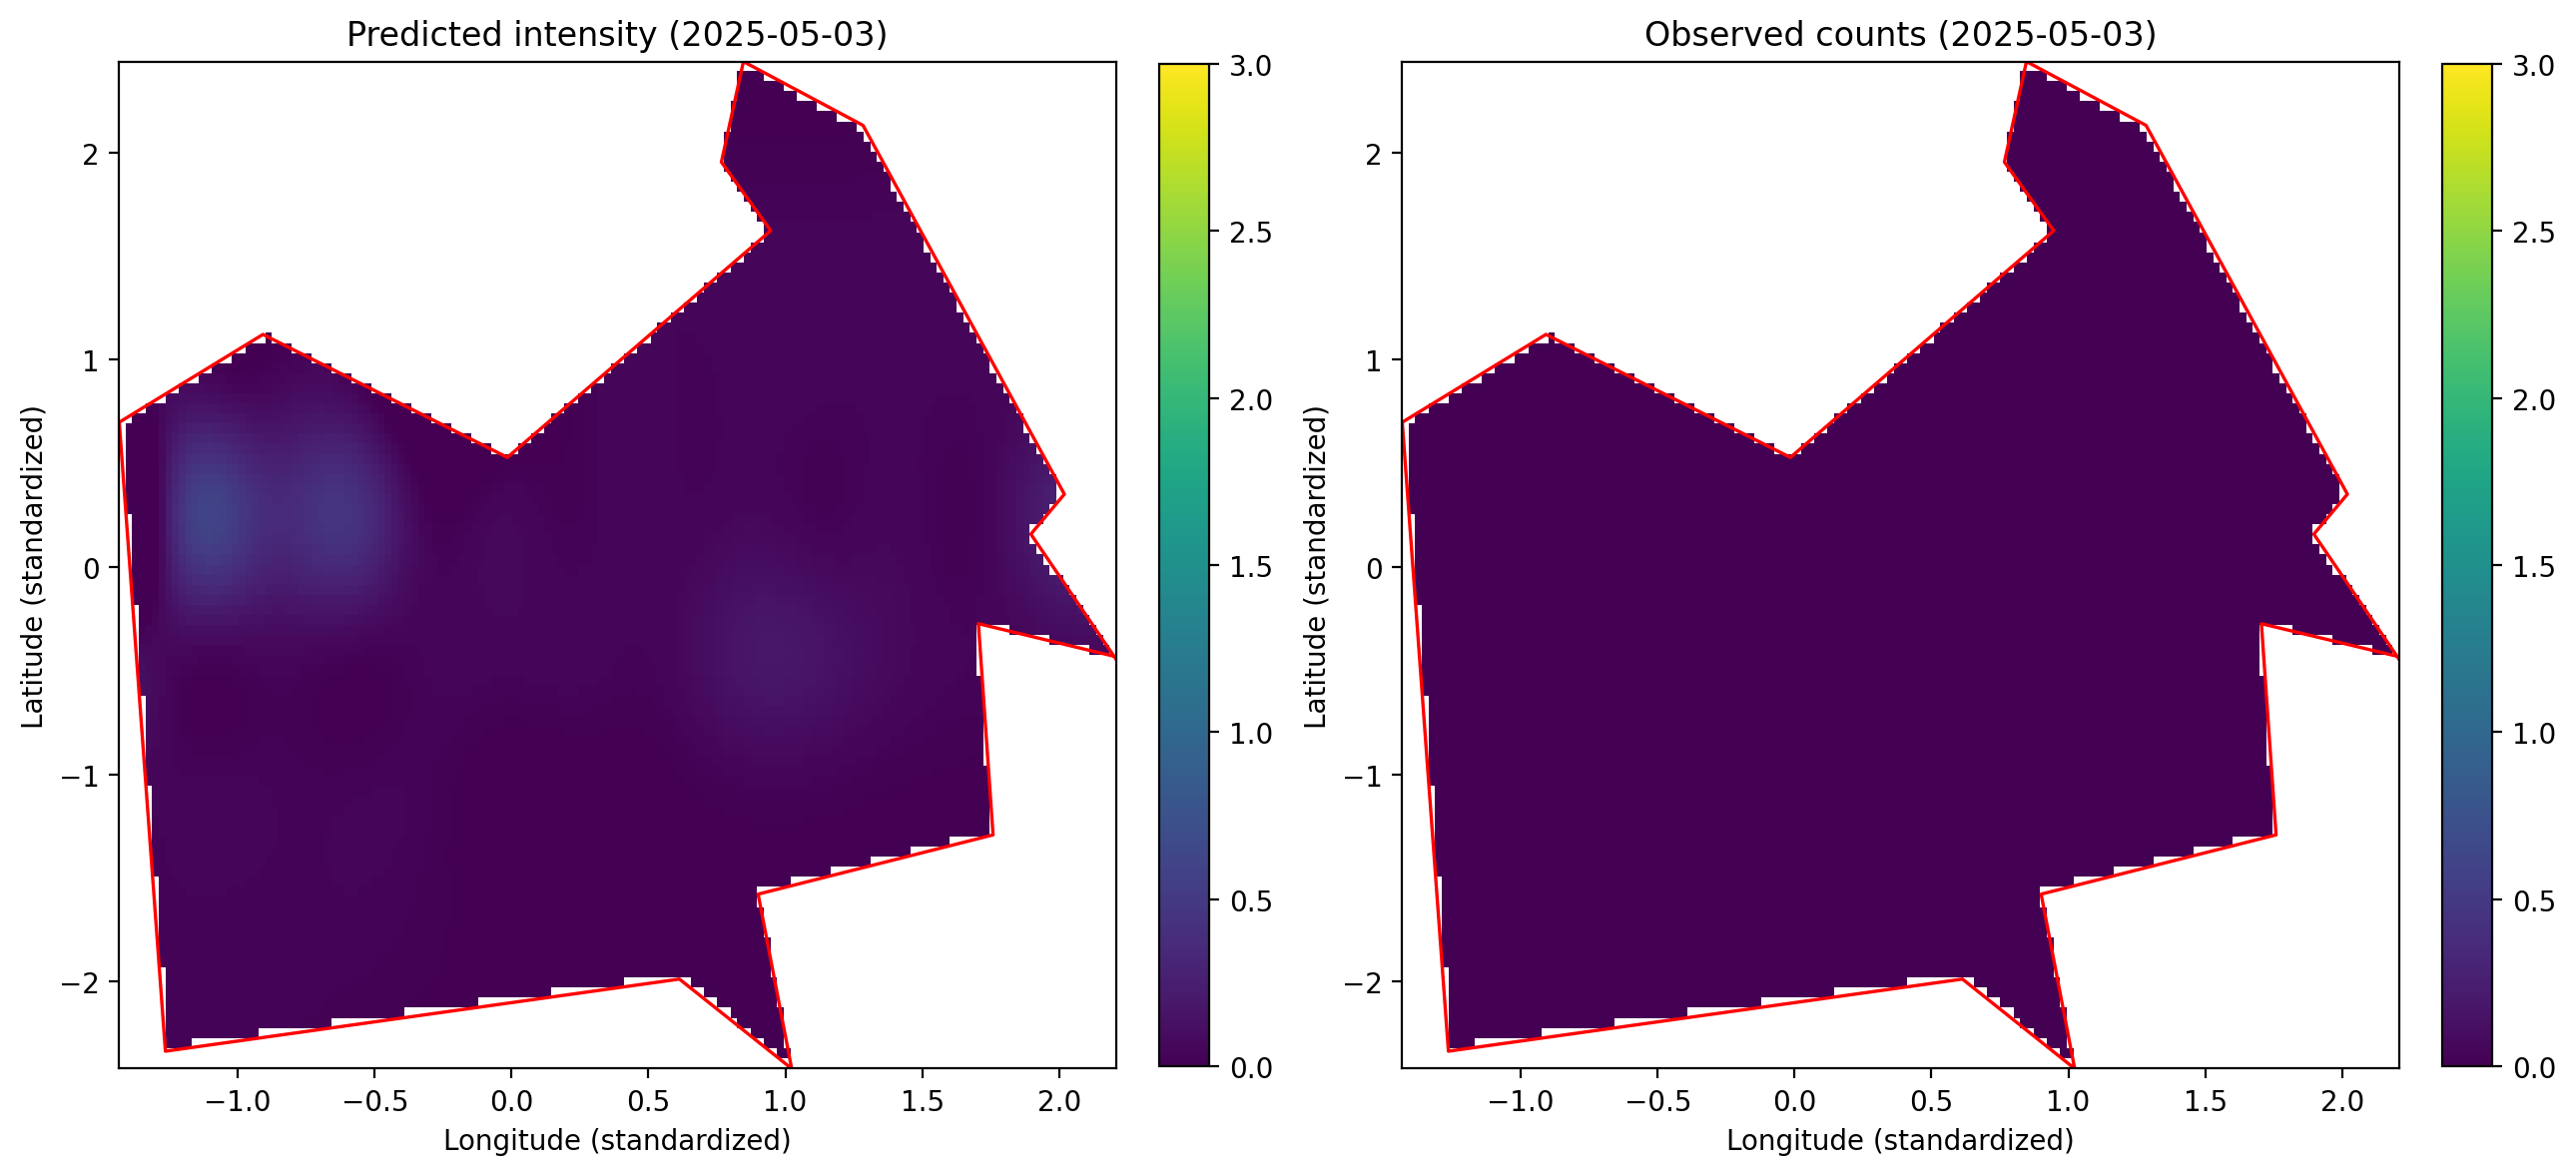

**GNN**

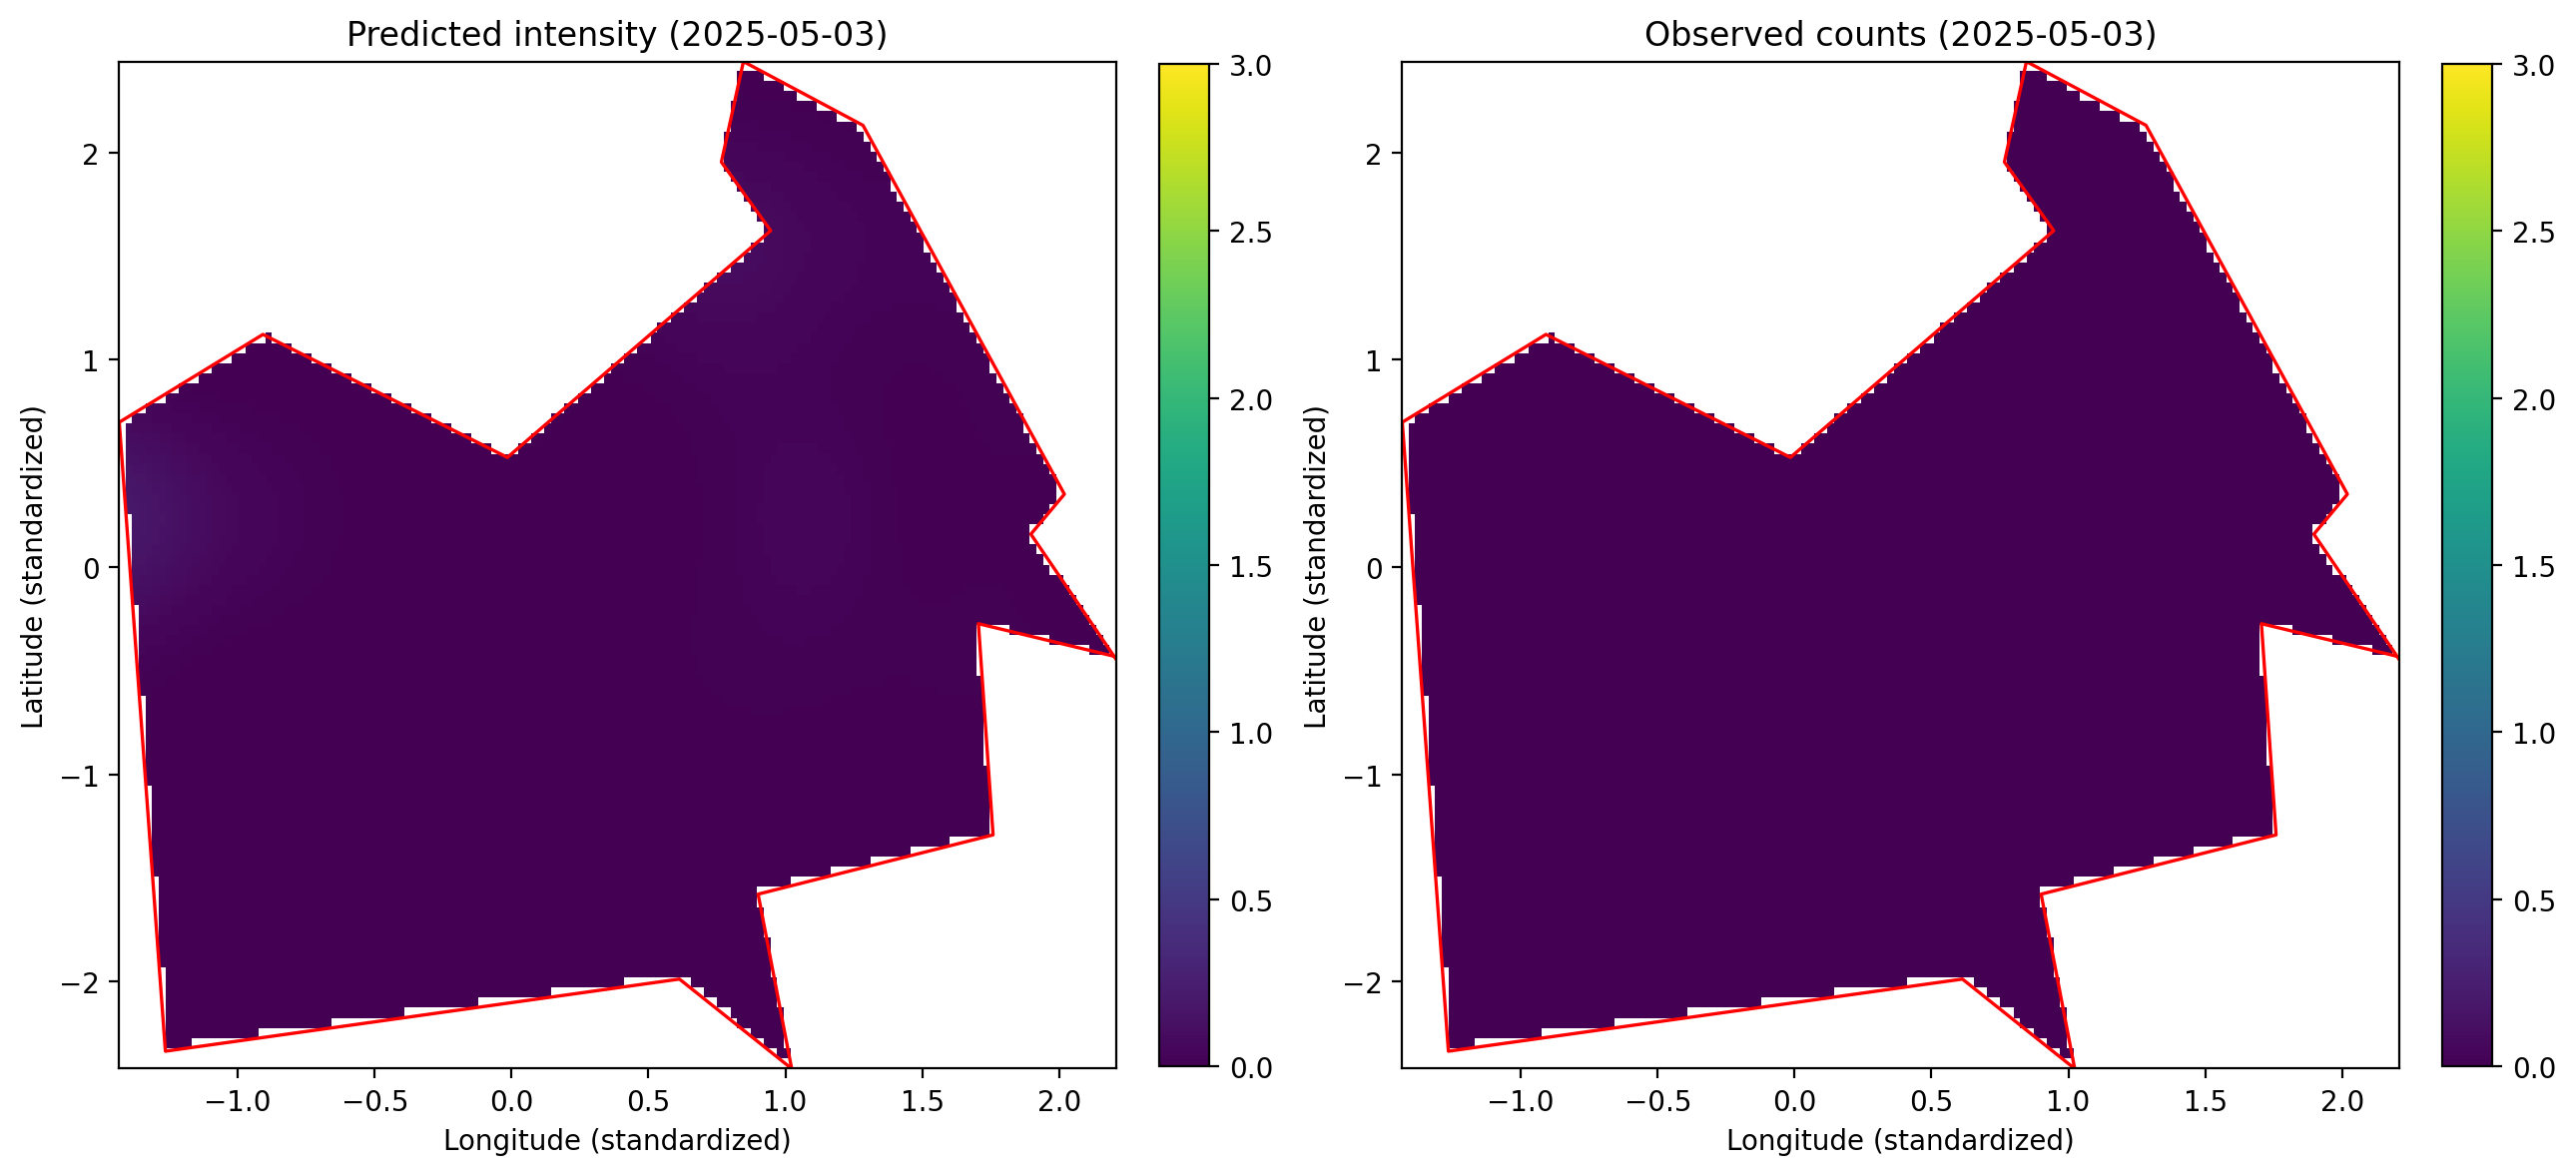

**LGCP (ours)**

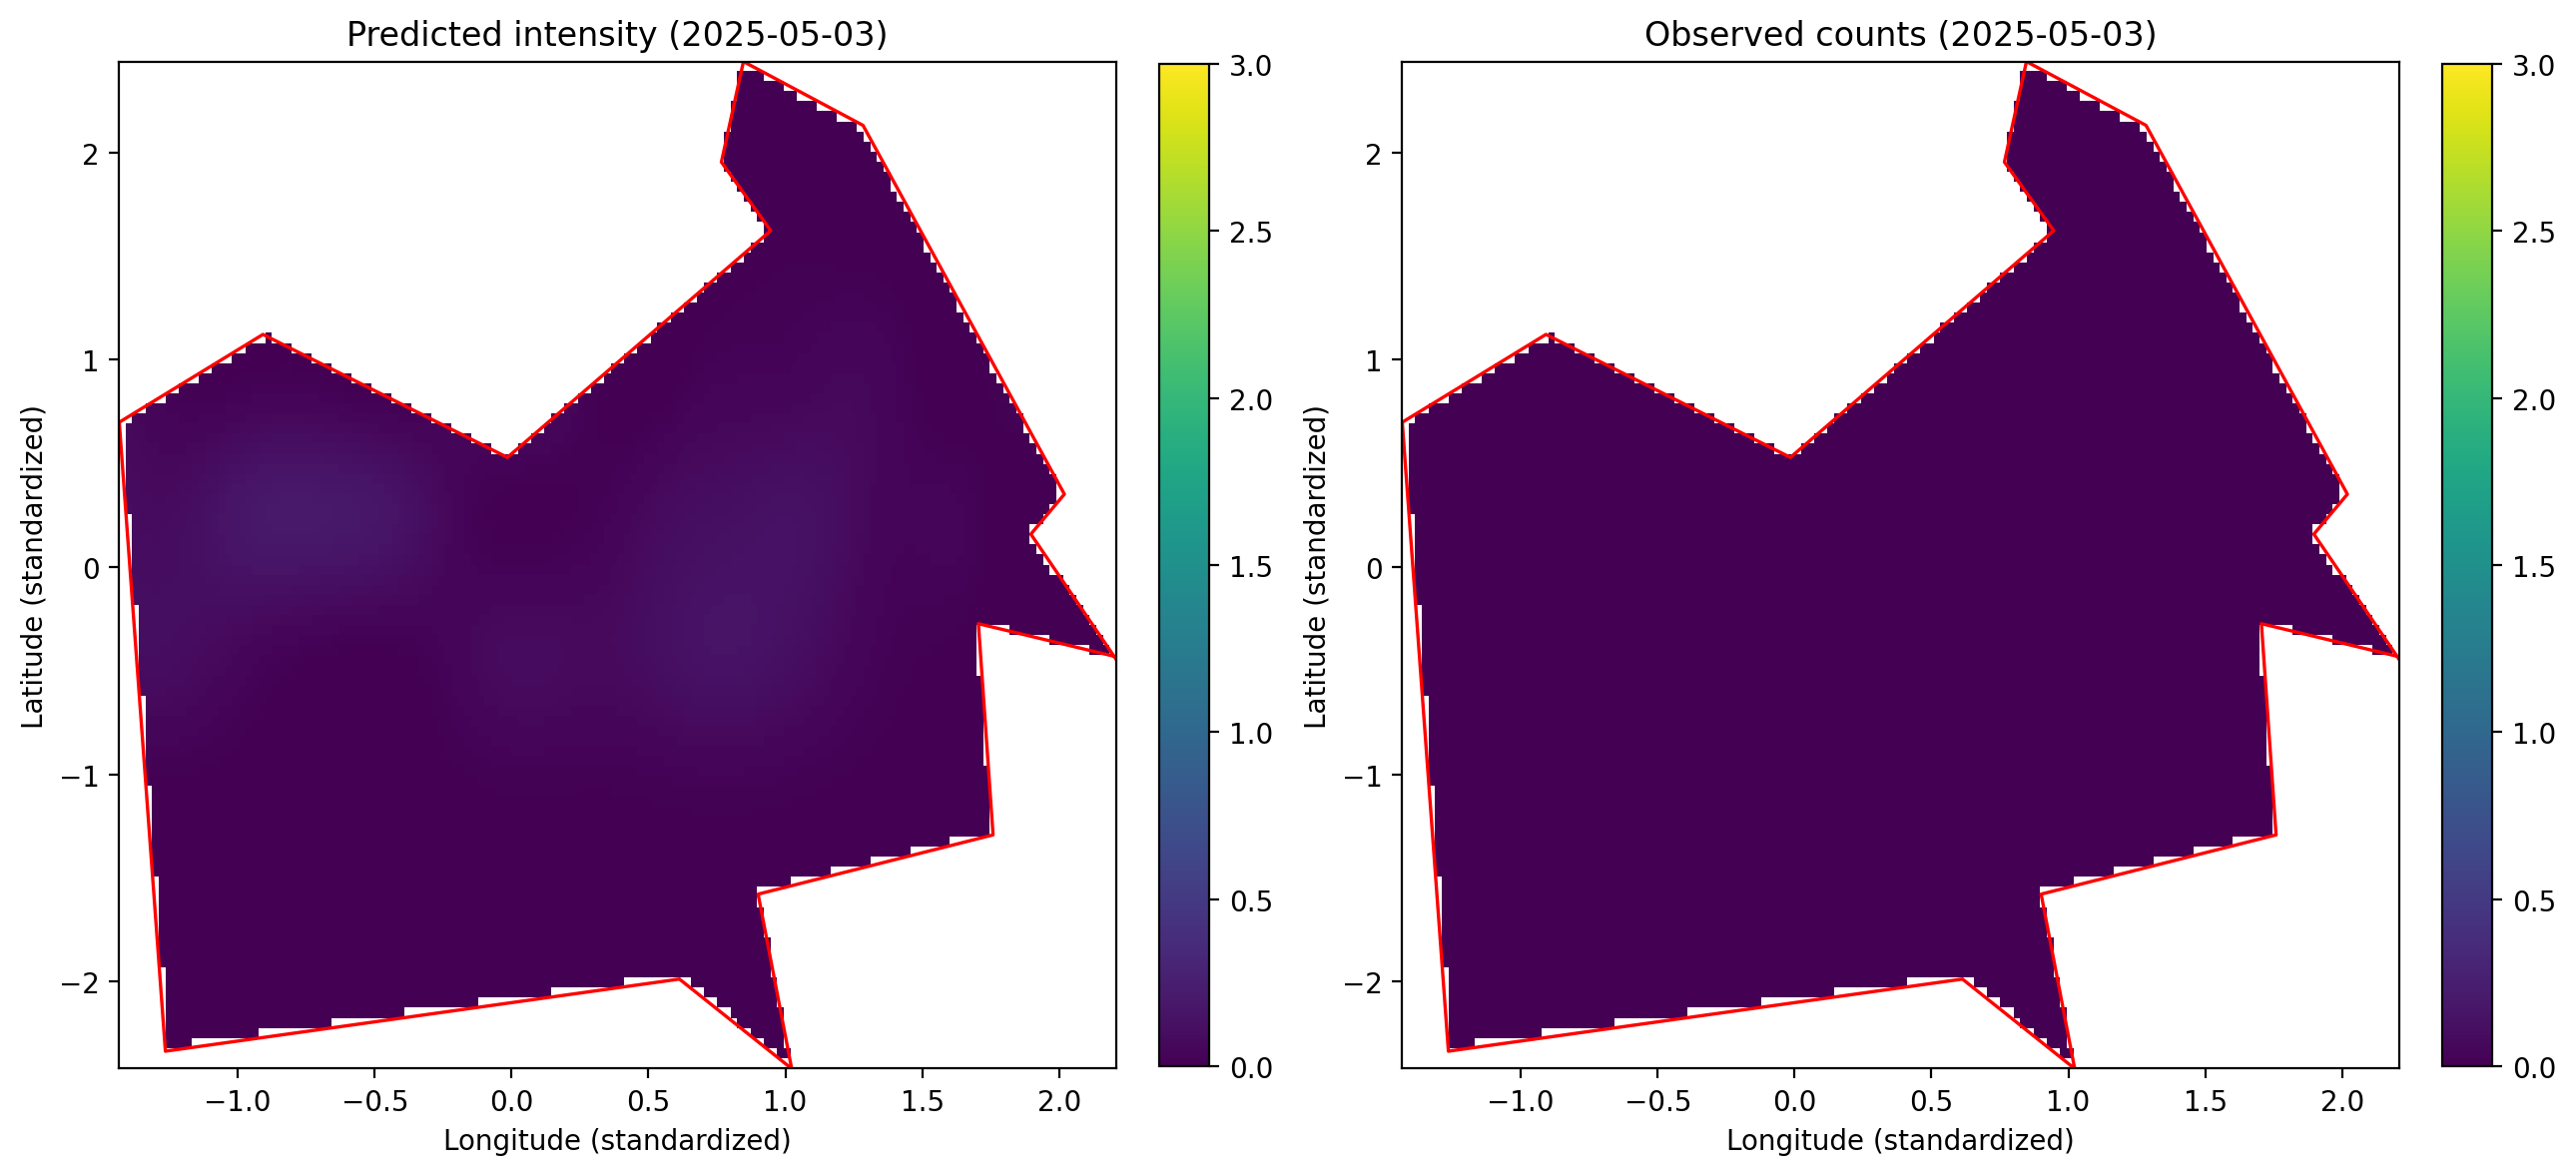

### November — 2025-11-03

**Last Available Poisson**

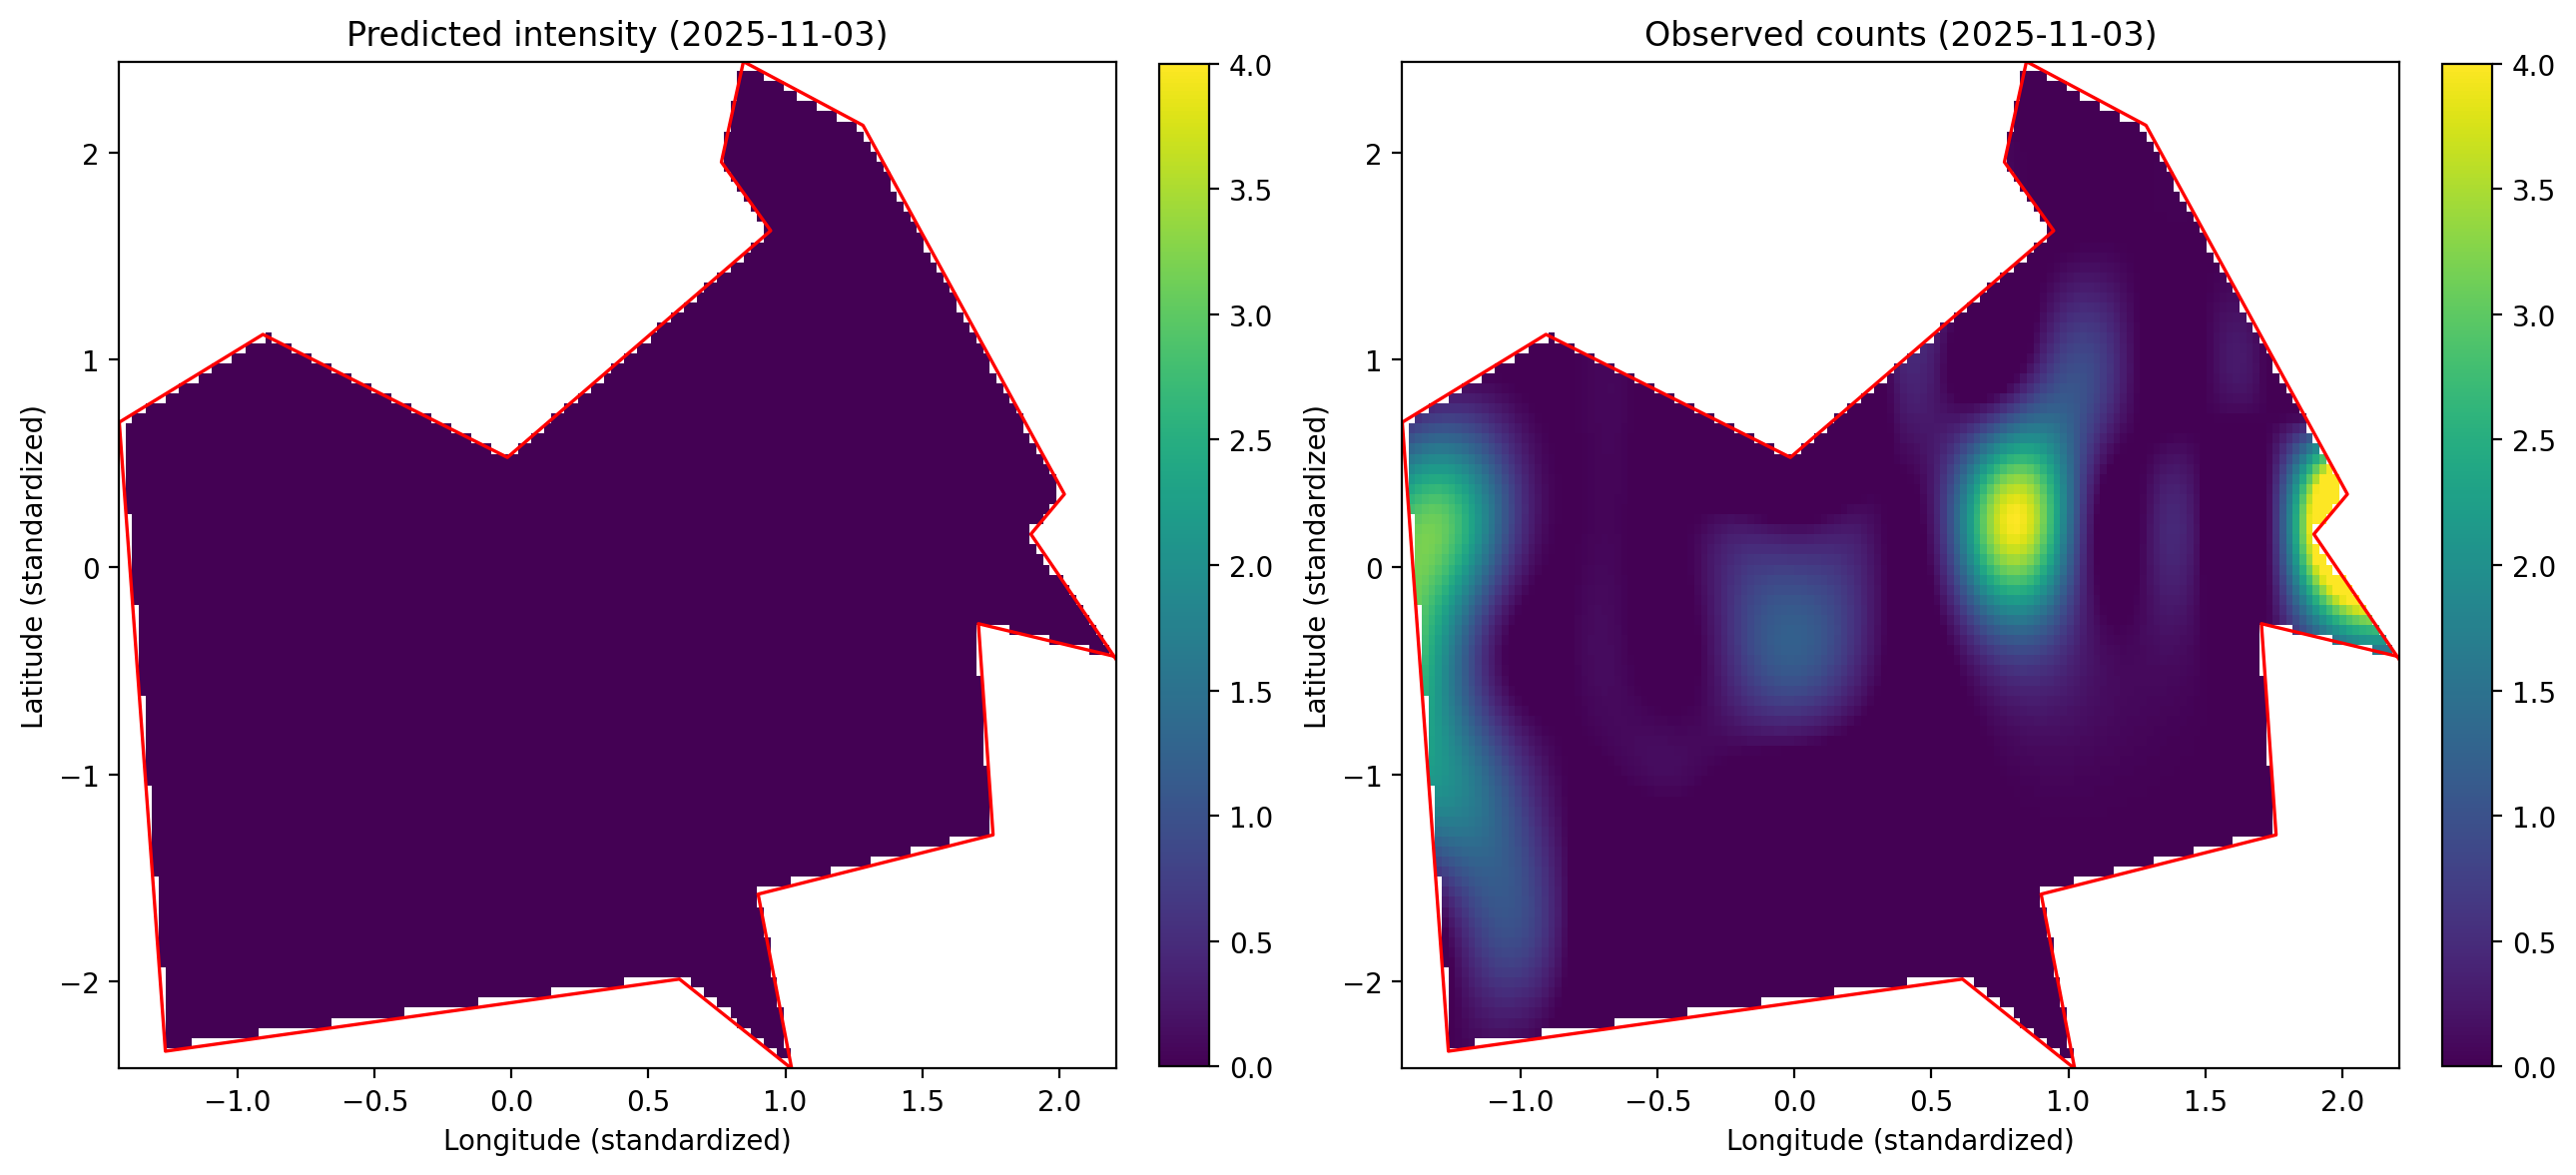

**Global Cell Mean Poisson**

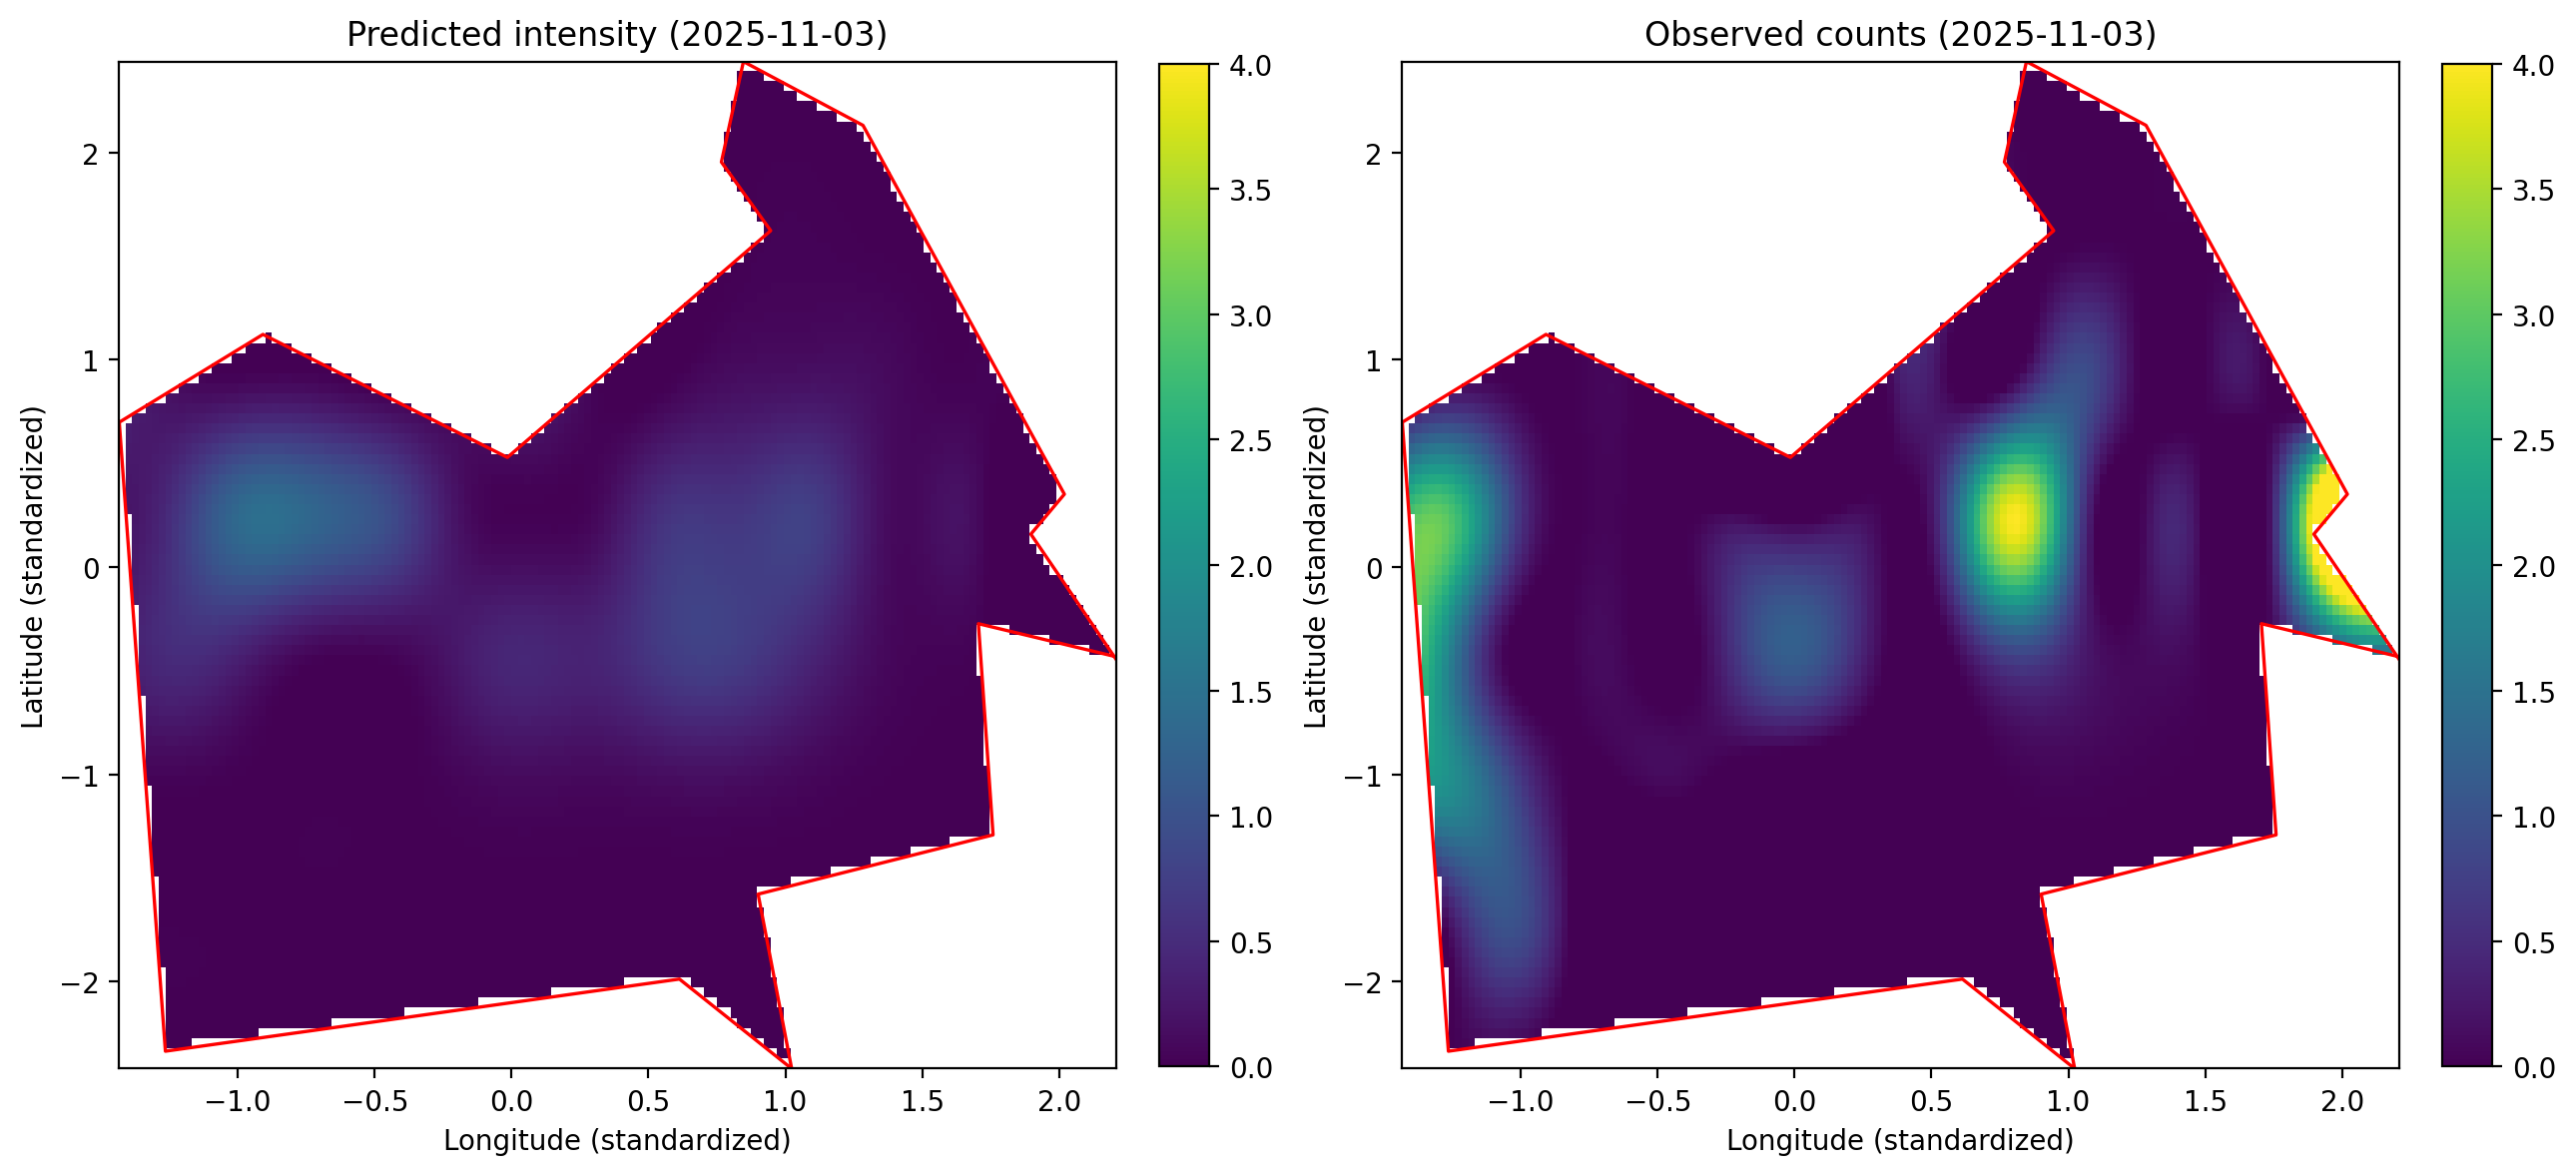

**Window Poisson GLM**

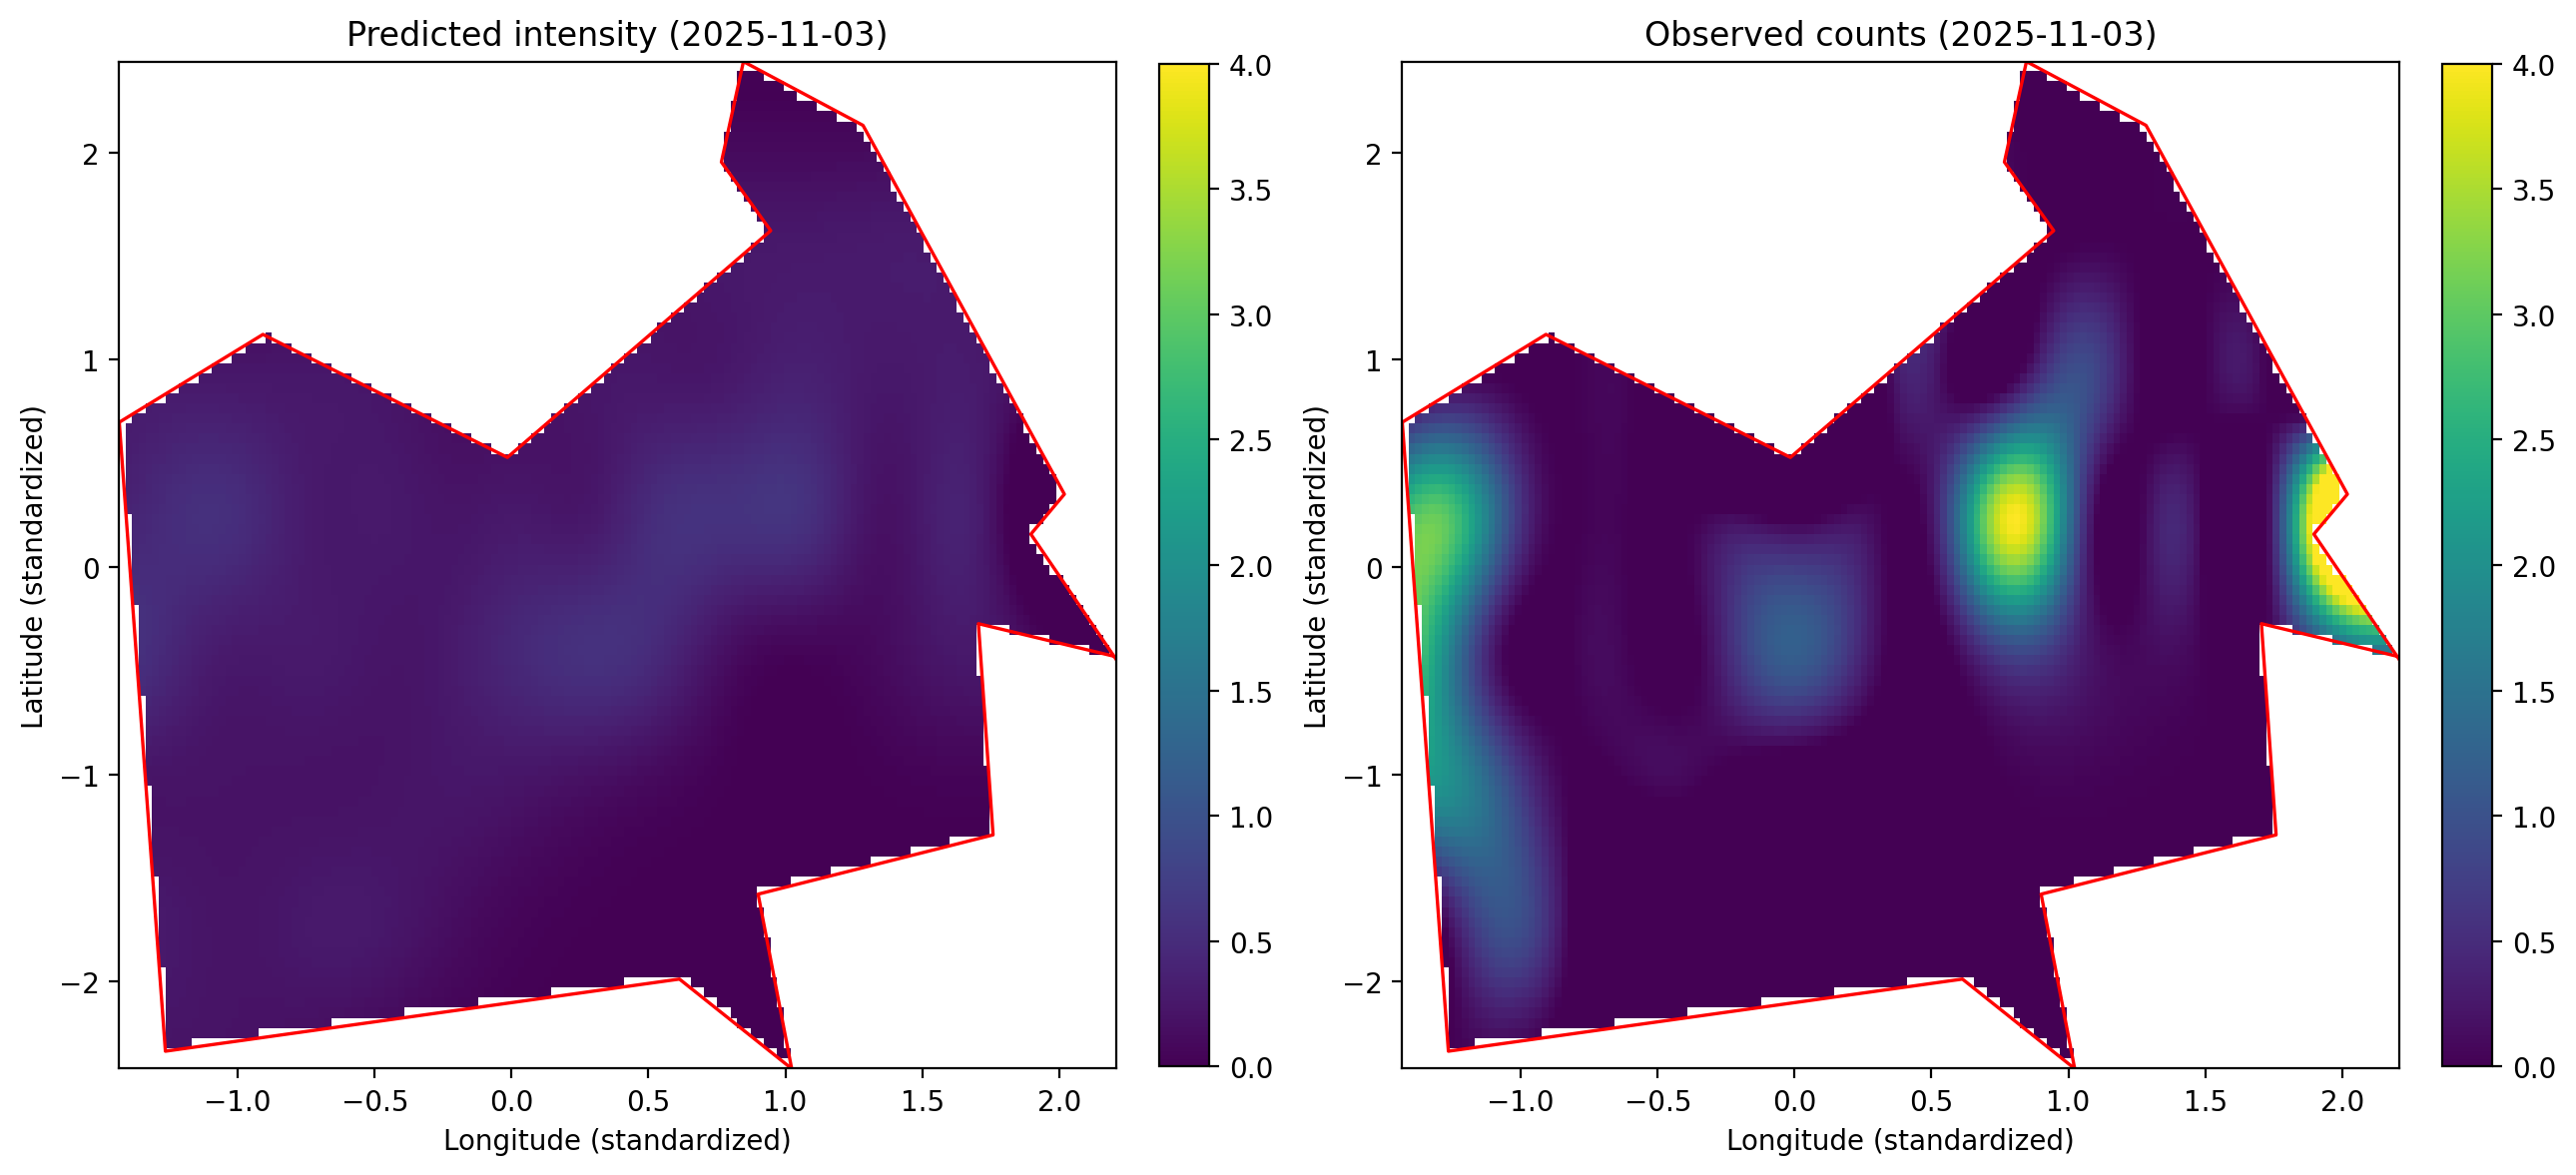

**GNN**

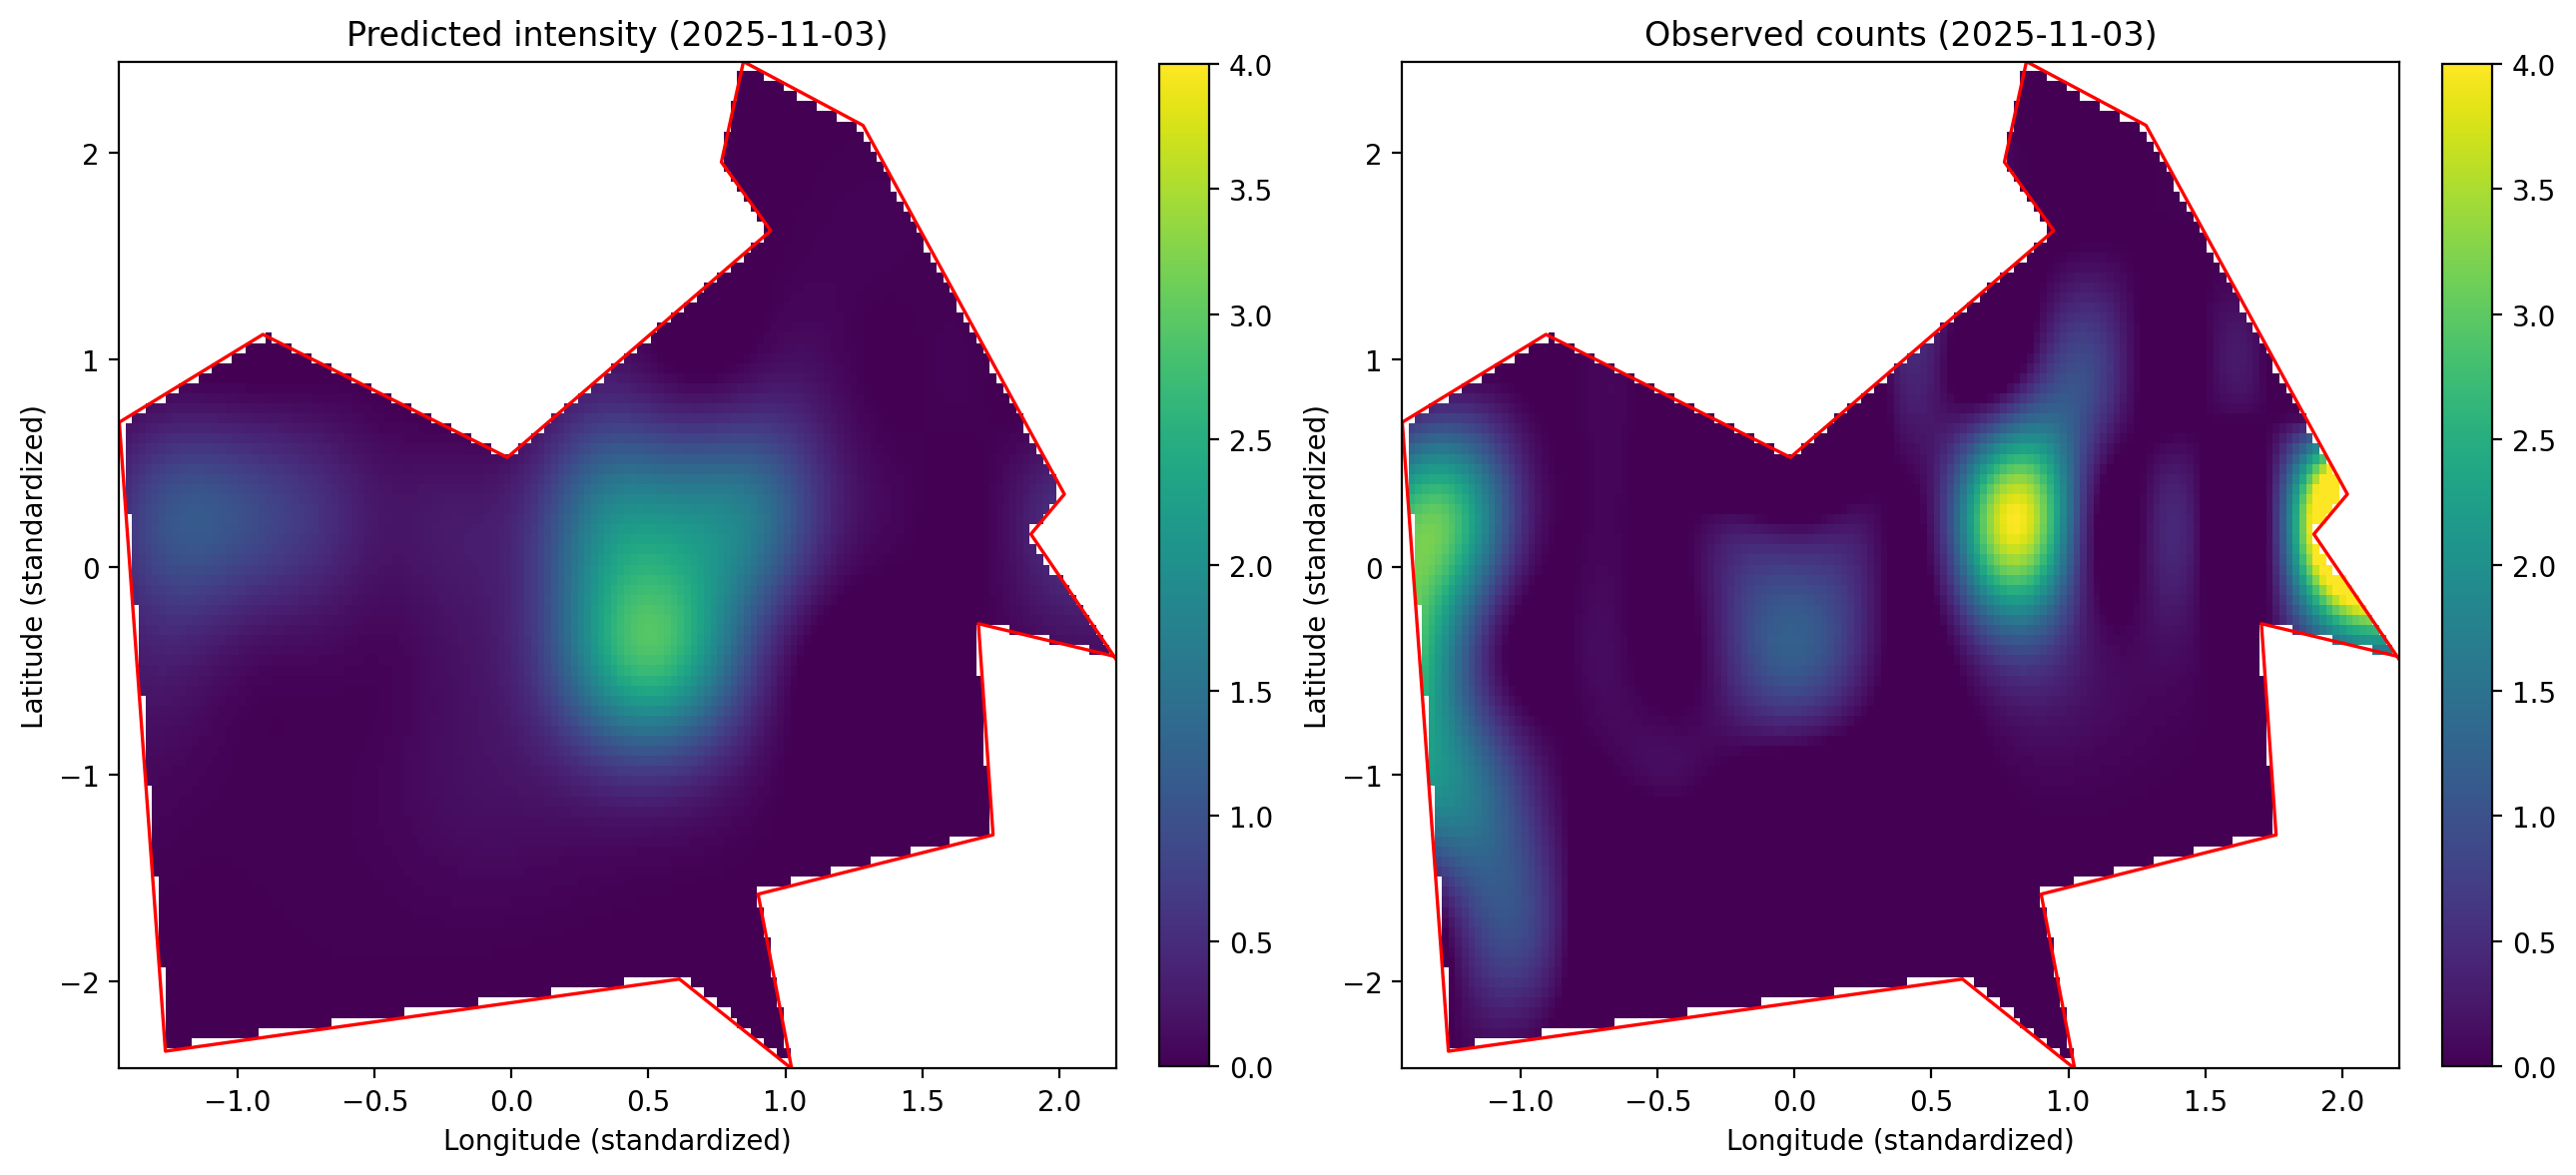

**LGCP (ours)**

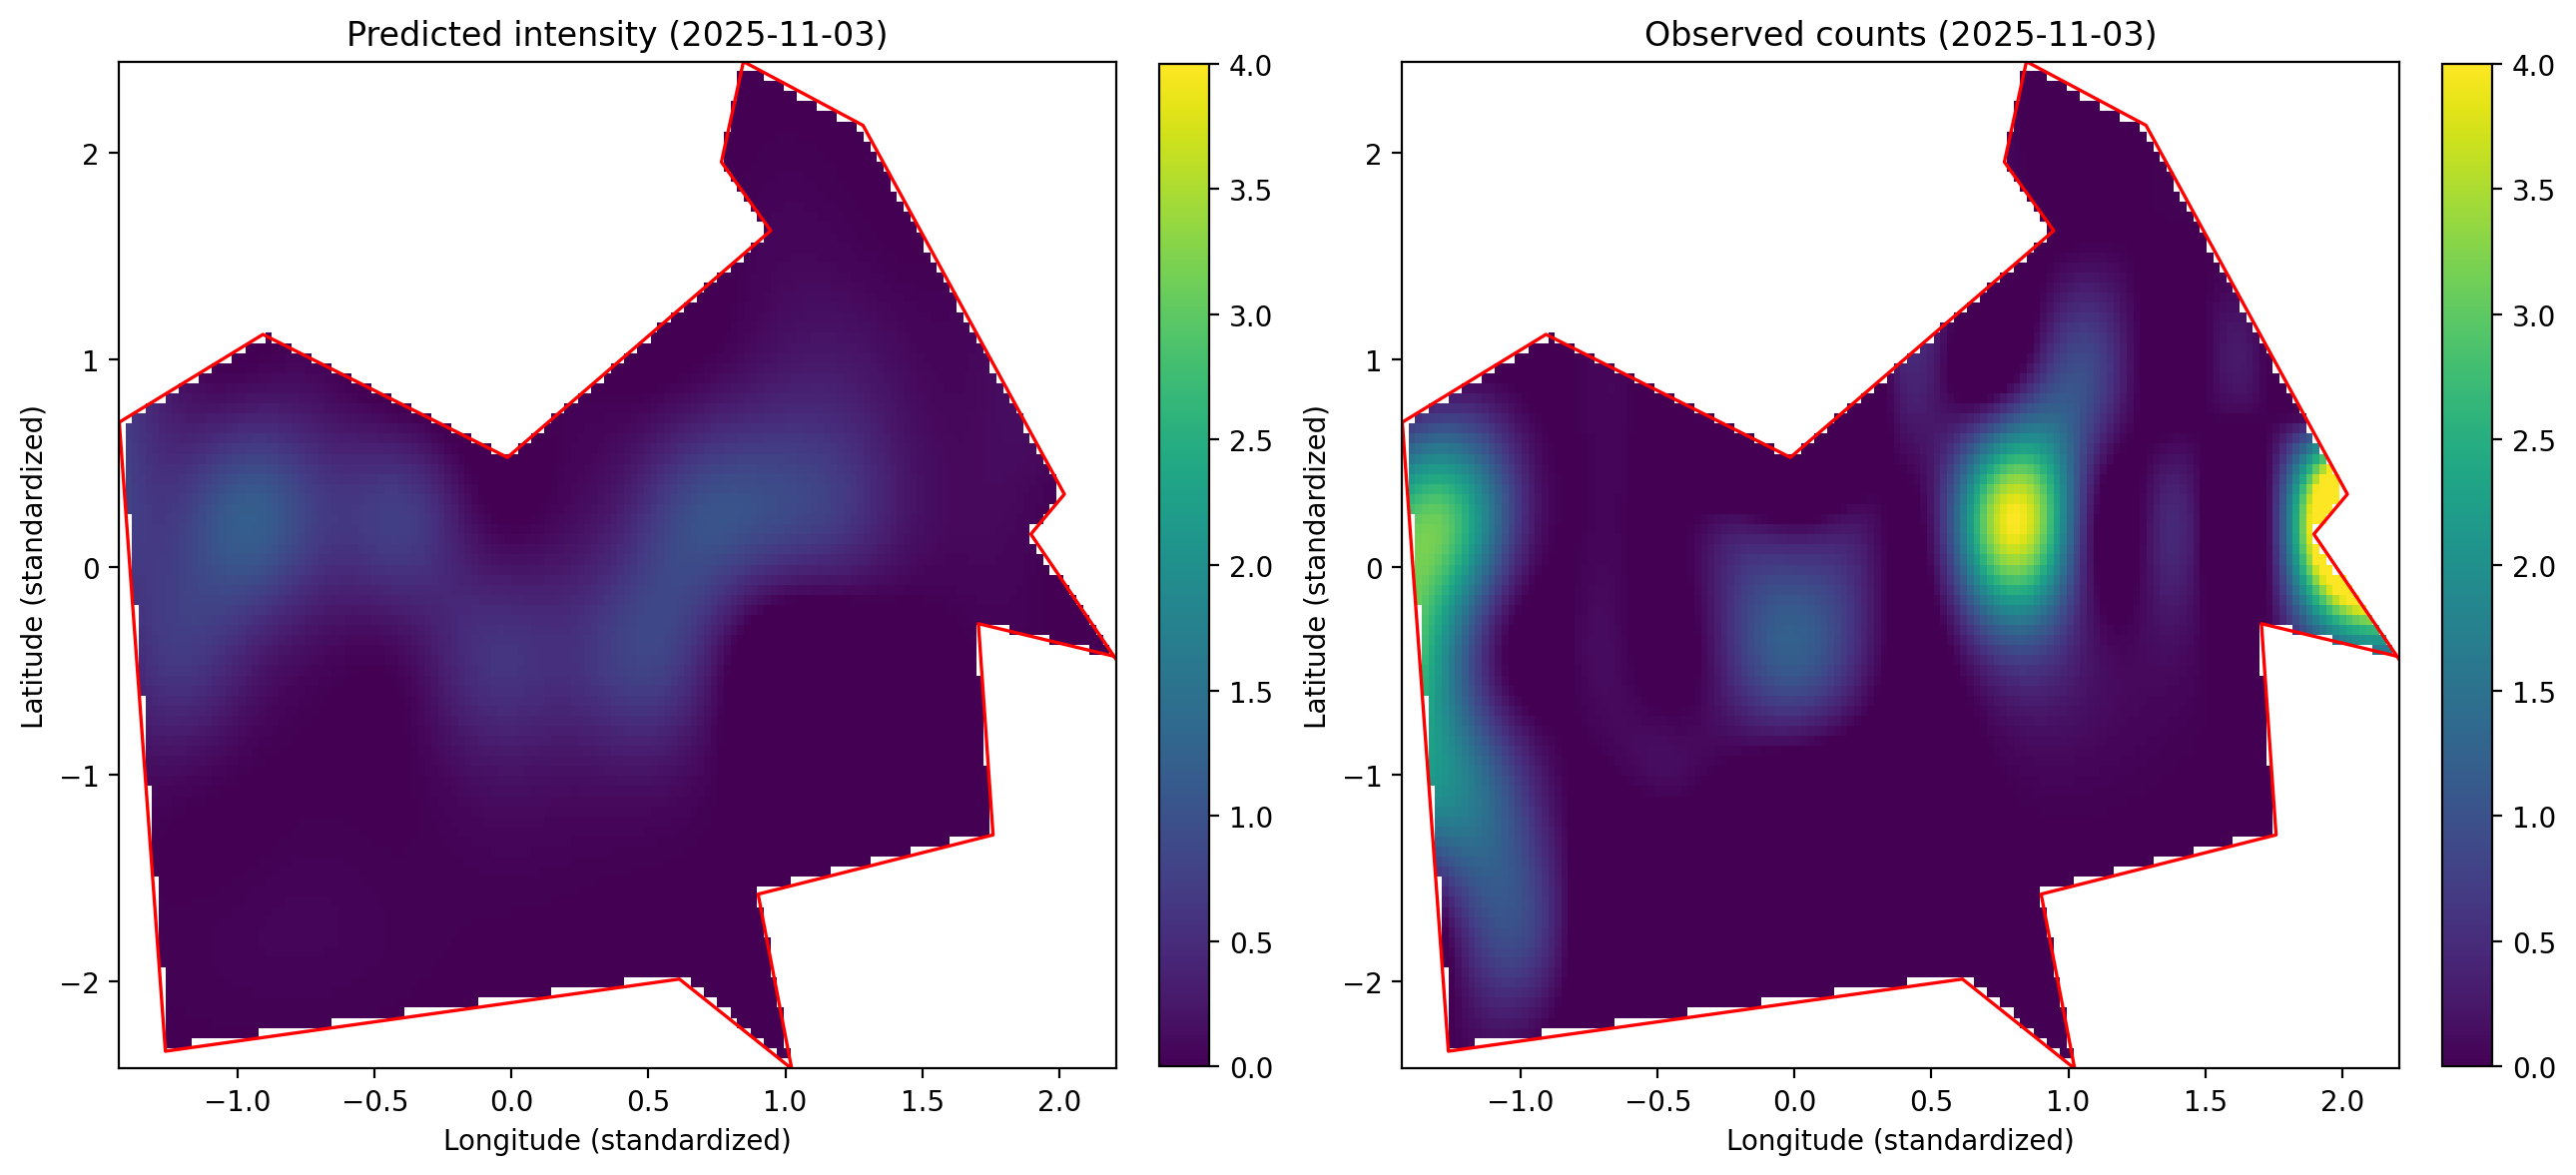

In [11]:
from IPython.display import Image, Markdown

METHOD_ORDER = ["last_available", "global_cell_mean", "window_glm", "gnn", "lgcp"]
METHOD_LABELS = {
    "last_available": "Last Available Poisson",
    "global_cell_mean": "Global Cell Mean Poisson",
    "window_glm": "Window Poisson GLM",
    "gnn": "GNN",
    "lgcp": "LGCP (ours)",
}

for week in REPORT_WEEKS:
    date_str = (pd.Timestamp(week["test_start"]) + pd.Timedelta(days=DAY_INDEX)).strftime("%Y-%m-%d")
    display(Markdown(f"### {week['label'].capitalize()} — {date_str}"))
    for method in METHOD_ORDER:
        img_path = PLOTS_DIR / f"spatial_map_{method}_{week['label']}_{date_str}.png"
        display(Markdown(f"**{METHOD_LABELS[method]}**"))
        display(Image(filename=str(img_path)))